In [803]:
# =============================================================================
# OULAD Data Exploration & ETL Pipeline
# Purpose: Load, explore, and merge OULAD tables to create ML-ready dataset
# =============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import warnings
import joblib
warnings.filterwarnings('ignore')

from sklearn.model_selection import (
    train_test_split, StratifiedKFold, cross_validate, RandomizedSearchCV
)
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix, classification_report
)
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from scipy.stats import randint, uniform
import shap


# OULAD Data Exploration & ETL Pipeline

## Project Goal
Build a **Student Success Prediction System** that identifies at-risk students early, enabling timely interventions.

## Dataset: Open University Learning Analytics Dataset (OULAD)
- **Source**: Open University UK (2017)
- **Size**: ~32,000 student-course enrollments across 7 courses
- **Time span**: 2013-2014 academic years

## Key Tables We'll Use
| Table | Description | Rows |
|-------|-------------|------|
| `studentInfo` | Demographics + **target variable** (final_result) | 32,593 |
| `studentAssessment` | Individual assessment scores | 173,912 |
| `studentVle` | Clickstream data (VLE interactions) | 10.6M |
| `studentRegistration` | Registration/unregistration dates | 32,593 |

## Our Approach
1. Load core student data (demographics + target)
2. Aggregate behavioral data (assessments, VLE clicks) per student-course
3. Handle missing values strategically
4. Create ML-ready feature set

---
## 1. Load Student Info (Core Table)

### Why start here?
`studentInfo` is our **anchor table** because it contains:
- **Unique identifier**: `id_student` + `code_module` + `code_presentation` (one row per student-course enrollment)
- **Target variable**: `final_result` (Pass, Fail, Withdrawn, Distinction)
- **Demographics**: gender, age_band, region, disability status
- **Academic background**: highest_education, num_of_prev_attempts

### Key Insight
A single student can appear **multiple times** if they enrolled in different courses. Each row represents a unique **student-course combination**, not a unique student.

In [804]:
# =============================================================================
# 1. LOAD STUDENT INFO (Core table with demographics + target variable)
# Contains: student demographics, education level, and final_result (our target)
# =============================================================================

students = pd.read_csv('../data/raw/studentInfo.csv')

In [805]:
# Check dataset size: 32,593 student records with 12 features
print(students.shape)

(32593, 12)


In [806]:
# View all columns - final_result is our target (Pass/Fail/Withdrawn/Distinction)
print(students.columns.tolist())

['code_module', 'code_presentation', 'id_student', 'gender', 'region', 'highest_education', 'imd_band', 'age_band', 'num_of_prev_attempts', 'studied_credits', 'disability', 'final_result']


In [807]:
# Preview first rows to understand data structure
print(students.head())

  code_module code_presentation  id_student gender                region  \
0         AAA             2013J       11391      M   East Anglian Region   
1         AAA             2013J       28400      F              Scotland   
2         AAA             2013J       30268      F  North Western Region   
3         AAA             2013J       31604      F     South East Region   
4         AAA             2013J       32885      F  West Midlands Region   

       highest_education imd_band age_band  num_of_prev_attempts  \
0       HE Qualification  90-100%     55<=                     0   
1       HE Qualification   20-30%    35-55                     0   
2  A Level or Equivalent   30-40%    35-55                     0   
3  A Level or Equivalent   50-60%    35-55                     0   
4     Lower Than A Level   50-60%     0-35                     0   

   studied_credits disability final_result  
0              240          N         Pass  
1               60          N         Pass  

---
## 2. Load Assessment Scores

### What this table contains
Each row = one assessment submission by one student:
- `id_assessment`: Links to assessment metadata (type, weight, due date)
- `score`: 0-100 scale
- `date_submitted`: Days relative to course start (negative = early)
- `is_banked`: Whether score was transferred from previous attempt

### Why assessments matter for prediction
- **Academic performance**: Average scores indicate understanding
- **Engagement signal**: Number of submissions shows participation
- Students who stop submitting often withdraw

In [808]:
# =============================================================================
# 2. LOAD ASSESSMENT SCORES
# Contains: individual assessment submissions with scores (0-100)
# Key insight: Multiple rows per student (one per assessment taken)
# =============================================================================

assessments = pd.read_csv('../data/raw/studentAssessment.csv')

print(assessments.shape)  # 173,912 assessment submissions
print(assessments.head())

(173912, 5)
   id_assessment  id_student  date_submitted  is_banked  score
0           1752       11391              18          0   78.0
1           1752       28400              22          0   70.0
2           1752       31604              17          0   72.0
3           1752       32885              26          0   69.0
4           1752       38053              19          0   79.0


In [809]:
# Merge students with assessments (temporary - for aggregation purposes)
# Using left join to keep all students even if they have no assessments
result = students.merge(assessments, on='id_student', how='left')

In [810]:
# After merge: rows expanded because each student has multiple assessments
print(result.shape)  # 213,166 rows (one per student-assessment pair)
result.head()

(213166, 16)


,code_module,code_presentation,id_student,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,final_result,id_assessment,date_submitted,is_banked,score
0,AAA,2013J,11391,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,N,Pass,1752.0,18.0,0.0,78.0
1,AAA,2013J,11391,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,N,Pass,1753.0,53.0,0.0,85.0
2,AAA,2013J,11391,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,N,Pass,1754.0,115.0,0.0,80.0
3,AAA,2013J,11391,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,N,Pass,1755.0,164.0,0.0,85.0
4,AAA,2013J,11391,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,N,Pass,1756.0,212.0,0.0,82.0


---
## 3. Aggregate Assessment Features

### The Granularity Problem (Critical!)

**Wrong approach** (what we initially had):
```python
# Groups by student only - WRONG!
student_agg = result.groupby('id_student').agg(...)
```
This averages a student's scores across ALL their courses, mixing signals.

**Correct approach**:
```python
# Groups by student + course - CORRECT!
student_agg = result.groupby(['id_student', 'code_module', 'code_presentation']).agg(...)
```
This keeps each course enrollment separate, preserving the true relationship between behavior and outcome.

### Why this matters
- Student A might score 90% in Course X but 50% in Course Y
- If we average to 70%, we lose the signal that predicts success in X and failure in Y
- Our **prediction unit** is student-course, so our **features** must be at student-course level

In [811]:
# =============================================================================
# 3. AGGREGATE ASSESSMENT FEATURES (per student-course)
# Goal: Create summary statistics from multiple assessments -> one row per student-course
# Features: avg_score (academic performance), assessment_count (engagement)
# FIX: Group by student + course to maintain proper granularity
# =============================================================================

student_agg = result.groupby(['id_student', 'code_module', 'code_presentation']).agg({
    'score': ['mean', 'count']
})

In [812]:
print(student_agg.head())
print(student_agg.shape)

                                         score      
                                          mean count
id_student code_module code_presentation            
3733       DDD         2013J               NaN     0
6516       AAA         2014J              61.8     5
8462       DDD         2013J              87.0     7
                       2014J              87.0     7
11391      AAA         2013J              82.0     5
(32593, 2)


In [813]:
# Flatten MultiIndex columns created by .agg() with multiple functions
# Before: ('score', 'mean'), ('score', 'count')
# After: 'avg_score', 'assessment_count'
student_agg.columns = ['avg_score', 'assessment_count']

In [814]:
# Reset index to make id_student a regular column (needed for merge)
student_agg = student_agg.reset_index()
student_agg.head()

,id_student,code_module,code_presentation,avg_score,assessment_count
0,3733,DDD,2013J,NaN,0
1,6516,AAA,2014J,61.8,5
2,8462,DDD,2013J,87.0,7
3,8462,DDD,2014J,87.0,7
4,11391,AAA,2013J,82.0,5


In [815]:
# Merge aggregated assessment features back to main students table
# Now merging on all three keys to maintain student-course granularity
students = students.merge(student_agg, on=['id_student', 'code_module', 'code_presentation'], how='left')

In [816]:
# Verify merge: still 32,593 rows (one per student), now with 14 columns (+2 new)
print(students.shape)
students.head()

(32593, 14)


,code_module,code_presentation,id_student,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,final_result,avg_score,assessment_count
0,AAA,2013J,11391,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,N,Pass,82.0,5
1,AAA,2013J,28400,F,Scotland,HE Qualification,20-30%,35-55,0,60,N,Pass,66.4,5
2,AAA,2013J,30268,F,North Western Region,A Level or Equivalent,30-40%,35-55,0,60,Y,Withdrawn,NaN,0
3,AAA,2013J,31604,F,South East Region,A Level or Equivalent,50-60%,35-55,0,60,N,Pass,76.0,5
4,AAA,2013J,32885,F,West Midlands Region,Lower Than A Level,50-60%,0-35,0,60,N,Pass,54.4,5


In [817]:
# Check for missing values in avg_score
# NaN means student has no assessment records (potential early dropout indicator)
print(f"Students with no assessments: {students['avg_score'].isna().sum()}")

Students with no assessments: 5866


---
## 4. Load VLE (Virtual Learning Environment) Data

### What is VLE data?
Clickstream data capturing every interaction with the online learning platform:
- Viewing lecture materials
- Accessing resources
- Participating in forums
- Submitting assignments

### Why VLE clicks are powerful predictors
| Behavior | Typical Outcome |
|----------|-----------------|
| High clicks early in course | Often succeeds |
| Declining click pattern | Warning sign |
| Zero clicks for weeks | Likely withdrawal |

### Scale consideration
With **10.6 million rows**, this is our largest table. We aggregate to avoid memory issues and create meaningful features.

In [818]:
# =============================================================================
# 4. LOAD VLE (Virtual Learning Environment) INTERACTIONS
# Contains: clickstream data - every interaction with course materials
# This is the LARGEST table (10M+ rows) - key engagement indicator
# =============================================================================

vle = pd.read_csv('../data/raw/studentVle.csv')
print(vle.shape)  # 10,655,280 interaction records
print(vle.head())

(10655280, 6)
  code_module code_presentation  id_student  id_site  date  sum_click
0         AAA             2013J       28400   546652   -10          4
1         AAA             2013J       28400   546652   -10          1
2         AAA             2013J       28400   546652   -10          1
3         AAA             2013J       28400   546614   -10         11
4         AAA             2013J       28400   546714   -10          1


---
## 5. Aggregate VLE Clicks

### What we are doing
Aggregate raw clickstream data (one row per interaction) into a single  feature per student-course:
- **Group by**: 
- **Aggregate**: sum all  values to produce 

### Why VLE engagement predicts risk
- Low click activity indicates a student is not engaging with materials, a strong at-risk signal
- Aggregating to student-course level maintains proper granularity (consistent with assessment data)

### Fix applied
Group by **student + course** (not just student), so each row still represents one student in one specific course.

In [819]:
# =============================================================================
# 5. AGGREGATE VLE CLICKS (per student-course)
# total_clicks = sum of all interactions with learning materials
# Higher clicks generally correlate with engagement and success
# FIX: Group by student + course to maintain proper granularity
# =============================================================================

agg_click = vle.groupby(['id_student', 'code_module', 'code_presentation']).agg({
    'sum_click': ['sum']
})

In [820]:
# Flatten column names
agg_click.columns = ['total_clicks']

In [821]:
# Reset index for merge
agg_click = agg_click.reset_index()
agg_click.head()

,id_student,code_module,code_presentation,total_clicks
0,6516,AAA,2014J,2791
1,8462,DDD,2013J,646
2,8462,DDD,2014J,10
3,11391,AAA,2013J,934
4,23629,BBB,2013B,161


In [822]:
# Merge VLE engagement features into main students table
# Now merging on all three keys to maintain student-course granularity
students = students.merge(agg_click, on=['id_student', 'code_module', 'code_presentation'], how='left')

---
## 6. Handle Missing Values

### Why do we have NaN values?
- **`avg_score = NaN`**: Student never submitted any assessments
- **`total_clicks = NaN`**: Student never accessed VLE
- **`imd_band = NaN`**: Missing socioeconomic data (students from Ireland/outside England)

### Our Strategy

**For engagement metrics** (avg_score, total_clicks): Fill with 0 + binary flag
- `avg_score = 0`: Accurately reflects no submissions
- `has_assessments = 0`: Model can learn "no submissions" ≠ "low scores"

**For imd_band**: Fix formatting + "Unknown" category
- **Issue 1**: Inconsistent format ("10-20" vs "10-20%") → standardize to "X-Y%"
- **Issue 2**: ~1,000 missing values → create "Unknown" category
- **Why "Unknown"?**: These are likely students from Ireland/Scotland where IMD doesn't apply. Dropping would lose data; imputing would be misleading.

### The `has_assessments` flag insight
A student with `avg_score=60, has_assessments=1` is very different from `avg_score=0, has_assessments=0`. The flag lets the model distinguish between:
- Low performer (submitted but scored poorly)
- Non-engager (never submitted at all)

In [823]:
# =============================================================================
# 6. HANDLE MISSING VALUES
# Students with no assessments/VLE activity get NaN - fill with 0
# Create binary flag to indicate if student submitted any assessments
# Also fix imd_band issues (missing values + inconsistent formatting)
# =============================================================================

# Fill missing values with 0 (no activity = zero engagement)
students['avg_score'] = students['avg_score'].fillna(0)
students['total_clicks'] = students['total_clicks'].fillna(0)

# Create binary flag: 1 if student submitted at least one assessment, else 0
students['has_assessments'] = (students['assessment_count'] > 0).astype(int)

# --- FIX imd_band issues ---
# 1. Check current state
print("imd_band BEFORE cleaning:")
print(f"  Missing values: {students['imd_band'].isna().sum()}")
print(f"  Unique values: {sorted(students['imd_band'].dropna().unique())}")

# 2. Fix inconsistent formatting (e.g., "10-20" → "10-20%")
students['imd_band'] = students['imd_band'].apply(
    lambda x: x + '%' if pd.notna(x) and not x.endswith('%') else x
)

# 3. Fill missing values with "Unknown" (better than dropping or imputing fake data)
students['imd_band'] = students['imd_band'].fillna('Unknown')

print("\nimd_band AFTER cleaning:")
print(f"  Missing values: {students['imd_band'].isna().sum()}")
print(f"  Unique values: {sorted(students['imd_band'].unique())}")

print(f"\nMissing avg_score after fill: {students['avg_score'].isna().sum()}")
print(f"Missing total_clicks after fill: {students['total_clicks'].isna().sum()}")

imd_band BEFORE cleaning:
  Missing values: 1111
  Unique values: ['0-10%', '10-20', '20-30%', '30-40%', '40-50%', '50-60%', '60-70%', '70-80%', '80-90%', '90-100%']

imd_band AFTER cleaning:
  Missing values: 0
  Unique values: ['0-10%', '10-20%', '20-30%', '30-40%', '40-50%', '50-60%', '60-70%', '70-80%', '80-90%', '90-100%', 'Unknown']

Missing avg_score after fill: 0
Missing total_clicks after fill: 0


In [824]:
# =============================================================================
# FINAL DATASET PREVIEW
# Now have: demographics + assessment stats + VLE engagement + engagement flag
# Each row = one student in one specific course (proper granularity)
# =============================================================================
print(f"Final shape: {students.shape}")
print(f"\nColumns: {students.columns.tolist()}")
print(f"\nSample data:")
students.head()

Final shape: (32593, 16)

Columns: ['code_module', 'code_presentation', 'id_student', 'gender', 'region', 'highest_education', 'imd_band', 'age_band', 'num_of_prev_attempts', 'studied_credits', 'disability', 'final_result', 'avg_score', 'assessment_count', 'total_clicks', 'has_assessments']

Sample data:


,code_module,code_presentation,id_student,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,final_result,avg_score,assessment_count,total_clicks,has_assessments
0,AAA,2013J,11391,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,N,Pass,82.0,5,934.0,1
1,AAA,2013J,28400,F,Scotland,HE Qualification,20-30%,35-55,0,60,N,Pass,66.4,5,1435.0,1
2,AAA,2013J,30268,F,North Western Region,A Level or Equivalent,30-40%,35-55,0,60,Y,Withdrawn,0.0,0,281.0,0
3,AAA,2013J,31604,F,South East Region,A Level or Equivalent,50-60%,35-55,0,60,N,Pass,76.0,5,2158.0,1
4,AAA,2013J,32885,F,West Midlands Region,Lower Than A Level,50-60%,0-35,0,60,N,Pass,54.4,5,1034.0,1


In [825]:
registration = pd.read_csv('../data/raw/studentRegistration.csv')
print(registration.shape)
registration.head()

(32593, 5)


,code_module,code_presentation,id_student,date_registration,date_unregistration
0,AAA,2013J,11391,-159.0,NaN
1,AAA,2013J,28400,-53.0,NaN
2,AAA,2013J,30268,-92.0,12.0
3,AAA,2013J,31604,-52.0,NaN
4,AAA,2013J,32885,-176.0,NaN


---
## 7. Create Binary Target Variable

### Original target: `final_result`
Four classes with imbalanced distribution:
- Pass
- Fail  
- Withdrawn
- Distinction

### Why convert to binary?
1. **Simpler model**: Binary classification is easier to train and interpret
2. **Actionable**: We care about "needs intervention" vs "on track"
3. **Class balance**: Combining Fail + Withdrawn gives better balance

### Our mapping:
| Original | Binary (`at_risk`) | Rationale |
|----------|-------------------|-----------|
| Pass | 0 (Success) | Completed course successfully |
| Distinction | 0 (Success) | Completed with honors |
| Fail | 1 (At-Risk) | Completed but failed - needed help |
| Withdrawn | 1 (At-Risk) | Dropped out - definitely needed intervention |

### Result
- **At-Risk (1)**: 17,208 students (52.8%)
- **Success (0)**: 15,385 students (47.2%)

This is a fairly balanced dataset - good for ML!

In [826]:
# Create binary target: 0 = Success, 1 = At-Risk
students['at_risk'] = students['final_result'].isin(['Fail', 'Withdrawn']).astype(int)



In [827]:
# Check distribution
print(students['at_risk'].value_counts())
print(students.groupby('final_result')['at_risk'].first())

at_risk
1    17208
0    15385
Name: count, dtype: int64
final_result
Distinction    0
Fail           1
Pass           0
Withdrawn      1
Name: at_risk, dtype: int64


In [828]:
students.to_csv('../data/processed/student_features.csv', index=False)

print(f"Saved {students.shape[0]} students with {students.shape[1]} features")

Saved 32593 students with 17 features


In [829]:
# Check if students appear multiple times
print(students['id_student'].value_counts().head())

id_student
584077    5
387276    4
542562    4
80329     4
157310    4
Name: count, dtype: int64


In [830]:
# =============================================================================
# PIPELINE SUMMARY
# =============================================================================
print("="*60)
print("ETL PIPELINE COMPLETE")
print("="*60)
print(f"\nFinal dataset: {students.shape[0]} rows x {students.shape[1]} columns")
print(f"\nFeatures created:")
print(f"  - avg_score: Mean assessment score (0 if no submissions)")
print(f"  - assessment_count: Number of assessments submitted")
print(f"  - total_clicks: Total VLE interactions")
print(f"  - has_assessments: Binary flag (1=submitted, 0=never submitted)")
print(f"  - at_risk: Target variable (1=Fail/Withdrawn, 0=Pass/Distinction)")
print(f"\nTarget distribution:")
print(students['at_risk'].value_counts())
print(f"\nSaved to: ../data/processed/student_features.csv")

ETL PIPELINE COMPLETE

Final dataset: 32593 rows x 17 columns

Features created:
  - avg_score: Mean assessment score (0 if no submissions)
  - assessment_count: Number of assessments submitted
  - total_clicks: Total VLE interactions
  - has_assessments: Binary flag (1=submitted, 0=never submitted)
  - at_risk: Target variable (1=Fail/Withdrawn, 0=Pass/Distinction)

Target distribution:
at_risk
1    17208
0    15385
Name: count, dtype: int64

Saved to: ../data/processed/student_features.csv


---
## Summary: Final ML-Ready Dataset

### Feature Set (13 columns)

**Categorical Features (7)**:
| Feature | Description |
|---------|-------------|
| `code_module` | Course code (AAA-GGG) - varies 29-62% at-risk rate |
| `gender` | M/F |
| `region` | UK region (13 values) |
| `highest_education` | Education level (5 values) |
| `imd_band` | Deprivation index - socioeconomic indicator |
| `age_band` | Age group (0-35, 35-55, 55<=) |
| `disability` | Y/N |

**Numerical Features (5)**:
| Feature | Correlation | Predictive Power |
|---------|-------------|-----------------|
| `completion_rate` | -0.63 | ⭐⭐⭐ Strongest |
| `avg_score` | -0.47 | ⭐⭐ Moderate |
| `total_clicks` | -0.35 | ⭐⭐ Moderate |
| `studied_credits` | ~0.05 | ⭐ Weak |
| `num_of_prev_attempts` | ~0.10 | ⭐ Weak |

**Target (1)**:
| Feature | Description |
|---------|-------------|
| `at_risk` | Binary: 1=Fail/Withdrawn, 0=Pass/Distinction |

### Columns Removed (6)
| Column | Reason |
|--------|--------|
| `id_student` | Identifier - no predictive value |
| `code_presentation` | Identifier (semester) |
| `final_result` | Redundant with `at_risk` |
| `assessment_count` | Redundant - captured in `completion_rate` |
| `has_assessments` | Redundant - `completion_rate=0` means no assessments |
| `total_assessments` | Course metadata - captured in `code_module` |

### Ready for XGBoost Training

In [831]:
# Check the new shape
print(students.shape)

# Verify granularity fix
print(students.groupby('id_student').size().value_counts())

# Check missing values
print(students[['avg_score', 'total_clicks', 'has_assessments']].isnull().sum())

(32593, 17)
1    25247
2     3293
3      221
4       23
5        1
Name: count, dtype: int64
avg_score          0
total_clicks       0
has_assessments    0
dtype: int64


In [832]:
# Check if rows are unique by student-course combo
duplicates = students.groupby(['id_student', 'code_module', 'code_presentation']).size()
print(duplicates[duplicates > 1])

# If empty, data is at student-course level ✓
# If not empty, we still have duplicates


Series([], dtype: int64)


In [833]:
students.head()

,code_module,code_presentation,id_student,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,final_result,avg_score,assessment_count,total_clicks,has_assessments,at_risk
0,AAA,2013J,11391,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,N,Pass,82.0,5,934.0,1,0
1,AAA,2013J,28400,F,Scotland,HE Qualification,20-30%,35-55,0,60,N,Pass,66.4,5,1435.0,1,0
2,AAA,2013J,30268,F,North Western Region,A Level or Equivalent,30-40%,35-55,0,60,Y,Withdrawn,0.0,0,281.0,0,1
3,AAA,2013J,31604,F,South East Region,A Level or Equivalent,50-60%,35-55,0,60,N,Pass,76.0,5,2158.0,1,0
4,AAA,2013J,32885,F,West Midlands Region,Lower Than A Level,50-60%,0-35,0,60,N,Pass,54.4,5,1034.0,1,0


In [834]:
students.sample(5)

,code_module,code_presentation,id_student,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,final_result,avg_score,assessment_count,total_clicks,has_assessments,at_risk
1771,BBB,2013B,541822,F,Yorkshire Region,A Level or Equivalent,0-10%,0-35,0,120,N,Distinction,79.100000,10,227.0,1,0
6074,BBB,2014B,631518,F,East Anglian Region,Lower Than A Level,60-70%,0-35,0,60,N,Withdrawn,0.000000,0,0.0,0,1
5242,BBB,2014B,560636,F,East Midlands Region,HE Qualification,40-50%,35-55,0,60,N,Withdrawn,0.000000,0,0.0,0,1
15911,DDD,2013J,601204,M,North Region,A Level or Equivalent,Unknown,0-35,0,60,N,Withdrawn,54.000000,5,447.0,1,1
16973,DDD,2014B,612326,M,Wales,A Level or Equivalent,30-40%,0-35,0,60,N,Distinction,79.857143,7,1919.0,1,0


---
## 8. Feature Engineering: Completion Rate

### Hypothesis
> Students who complete fewer assessments relative to what's available are at higher risk.

### Why this might be better than raw `assessment_count`
- **Problem with raw count**: Course AAA has 6 assessments, Course DDD has 14. A student completing 5 in AAA (83%) looks the same as 5 in DDD (36%).
- **Solution**: Normalize by what's available → `completion_rate = assessment_count / total_assessments`

### Data source
`assessments.csv` contains assessment metadata (one row per assessment per course), NOT student submissions.

In [835]:
# =============================================================================
# STEP 1: Load assessment metadata and count assessments per course
# =============================================================================

# Load assessment definitions (NOT student submissions)
assessment_meta = pd.read_csv('../data/raw/assessments.csv')
print(f"Assessment metadata: {assessment_meta.shape}")
print(assessment_meta.head())

Assessment metadata: (206, 6)
  code_module code_presentation  id_assessment assessment_type   date  weight
0         AAA             2013J           1752             TMA   19.0    10.0
1         AAA             2013J           1753             TMA   54.0    20.0
2         AAA             2013J           1754             TMA  117.0    20.0
3         AAA             2013J           1755             TMA  166.0    20.0
4         AAA             2013J           1756             TMA  215.0    30.0


In [836]:
# Count total assessments per course (code_module + code_presentation)
course_assessments = assessment_meta.groupby(['code_module', 'code_presentation']).size().reset_index(name='total_assessments')

print("Assessments per course:")
print(course_assessments)
print(f"\nRange: {course_assessments['total_assessments'].min()} to {course_assessments['total_assessments'].max()} assessments")

Assessments per course:
   code_module code_presentation  total_assessments
0          AAA             2013J                  6
1          AAA             2014J                  6
2          BBB             2013B                 12
3          BBB             2013J                 12
4          BBB             2014B                 12
5          BBB             2014J                  6
6          CCC             2014B                 10
7          CCC             2014J                 10
8          DDD             2013B                 14
9          DDD             2013J                  7
10         DDD             2014B                  7
11         DDD             2014J                  7
12         EEE             2013J                  5
13         EEE             2014B                  5
14         EEE             2014J                  5
15         FFF             2013B                 13
16         FFF             2013J                 13
17         FFF             2014B        

In [837]:
# =============================================================================
# STEP 2: Merge total_assessments with students data
# =============================================================================

students = students.merge(course_assessments, on=['code_module', 'code_presentation'], how='left')

print(f"Shape after merge: {students.shape}")
print(f"Missing total_assessments: {students['total_assessments'].isna().sum()}")

Shape after merge: (32593, 18)
Missing total_assessments: 0


In [838]:
# =============================================================================
# STEP 3: Create completion_rate feature
# =============================================================================

students['completion_rate'] = students['assessment_count'] / students['total_assessments']

# Preview the new feature
print("Completion rate statistics:")
print(students['completion_rate'].describe())
print(f"\nSample data:")
students[['code_module', 'id_student', 'assessment_count', 'total_assessments', 'completion_rate', 'at_risk']].head(10)

Completion rate statistics:
count    32593.000000
mean         0.659435
std          0.519877
min          0.000000
25%          0.153846
50%          0.800000
75%          0.923077
max          5.000000
Name: completion_rate, dtype: float64

Sample data:


,code_module,id_student,assessment_count,total_assessments,completion_rate,at_risk
0,AAA,11391,5,6,0.833333,0
1,AAA,28400,5,6,0.833333,0
2,AAA,30268,0,6,0.000000,1
3,AAA,31604,5,6,0.833333,0
4,AAA,32885,5,6,0.833333,0
5,AAA,38053,5,6,0.833333,0
6,AAA,45462,5,6,0.833333,0
7,AAA,45642,5,6,0.833333,0
8,AAA,52130,5,6,0.833333,0
9,AAA,53025,5,6,0.833333,0


---
### Correlation Analysis

**Goal**: Test if `completion_rate` correlates with `at_risk` better than raw `assessment_count`.

**Interpretation**:
- **Negative correlation** = higher completion → lower risk (what we expect)
- **Stronger correlation** = more predictive power

In [839]:
# =============================================================================
# STEP 4: Correlation analysis - completion_rate vs at_risk
# =============================================================================

# Pearson correlation with target
corr_completion = students['completion_rate'].corr(students['at_risk'])
corr_count = students['assessment_count'].corr(students['at_risk'])

print("="*60)
print("CORRELATION WITH at_risk (target)")
print("="*60)
print(f"\ncompletion_rate:   {corr_completion:.4f}")
print(f"assessment_count:  {corr_count:.4f}")
print(f"\nDifference: {abs(corr_completion) - abs(corr_count):.4f}")

if abs(corr_completion) > abs(corr_count):
    print("\n✓ completion_rate has STRONGER correlation with at_risk")
else:
    print("\n✗ assessment_count has stronger correlation")

CORRELATION WITH at_risk (target)

completion_rate:   -0.6271
assessment_count:  -0.6124

Difference: 0.0147

✓ completion_rate has STRONGER correlation with at_risk


In [840]:
# =============================================================================
# STEP 5: Compare means by outcome group
# =============================================================================

print("Mean completion_rate by outcome:")
print(students.groupby('final_result')['completion_rate'].mean().sort_values())

print("\n" + "="*60)
print("Mean assessment_count by outcome:")
print(students.groupby('final_result')['assessment_count'].mean().sort_values())

Mean completion_rate by outcome:
final_result
Withdrawn      0.266535
Fail           0.473106
Pass           0.993865
Distinction    1.046468
Name: completion_rate, dtype: float64

Mean assessment_count by outcome:
final_result
Withdrawn       2.547263
Fail            4.664492
Pass            9.544940
Distinction    10.034061
Name: assessment_count, dtype: float64


In [841]:
# =============================================================================
# STEP 6: Visual comparison - At-Risk vs Success
# =============================================================================

print("="*60)
print("COMPLETION RATE BY RISK STATUS")
print("="*60)

risk_comparison = students.groupby('at_risk').agg({
    'completion_rate': ['mean', 'median', 'std'],
    'assessment_count': ['mean', 'median', 'std']
}).round(3)

print(risk_comparison)

print("\n" + "="*60)
print("KEY INSIGHT")
print("="*60)
success_rate = students[students['at_risk'] == 0]['completion_rate'].mean()
atrisk_rate = students[students['at_risk'] == 1]['completion_rate'].mean()
print(f"Success students complete: {success_rate:.1%} of assessments")
print(f"At-risk students complete: {atrisk_rate:.1%} of assessments")
print(f"Gap: {(success_rate - atrisk_rate):.1%}")

COMPLETION RATE BY RISK STATUS
        completion_rate               assessment_count              
                   mean median    std             mean median    std
at_risk                                                             
0                 1.004  0.917  0.378            9.641   10.0  3.784
1                 0.351  0.200  0.428            3.415    2.0  4.207

KEY INSIGHT
Success students complete: 100.4% of assessments
At-risk students complete: 35.1% of assessments
Gap: 65.3%


---
### Recommendation

**Keep `completion_rate`?** Run the cells above to see the correlation results.

**Expected outcome**:
- If `completion_rate` has stronger negative correlation → **KEEP IT** (normalizing helps)
- If correlations are similar → **KEEP BOTH** (they capture different signals)
- If `assessment_count` is stronger → Consider keeping only raw count

**Why keep both might make sense**:
- `completion_rate`: Relative engagement (% of course completed)
- `assessment_count`: Absolute engagement (total submissions)
- A student with 3/6 (50%) might behave differently than 7/14 (50%) despite same rate

**For XGBoost**: Tree-based models can learn interactions, so including both lets the model decide which matters more in different contexts.

In [842]:
# =============================================================================
# Save updated dataset with new features
# =============================================================================

students.to_csv('../data/processed/student_features.csv', index=False)

print(f"Updated dataset saved: {students.shape[0]} rows x {students.shape[1]} columns")
print(f"\nNew columns added:")
print(f"  - total_assessments: Number of assessments available in the course")
print(f"  - completion_rate: assessment_count / total_assessments")
print(f"\nAll columns: {students.columns.tolist()}")

Updated dataset saved: 32593 rows x 19 columns

New columns added:
  - total_assessments: Number of assessments available in the course
  - completion_rate: assessment_count / total_assessments

All columns: ['code_module', 'code_presentation', 'id_student', 'gender', 'region', 'highest_education', 'imd_band', 'age_band', 'num_of_prev_attempts', 'studied_credits', 'disability', 'final_result', 'avg_score', 'assessment_count', 'total_clicks', 'has_assessments', 'at_risk', 'total_assessments', 'completion_rate']


In [843]:
students.head(20)

,code_module,code_presentation,id_student,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,final_result,avg_score,assessment_count,total_clicks,has_assessments,at_risk,total_assessments,completion_rate
0,AAA,2013J,11391,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,N,Pass,82.0,5,934.0,1,0,6,0.833333
1,AAA,2013J,28400,F,Scotland,HE Qualification,20-30%,35-55,0,60,N,Pass,66.4,5,1435.0,1,0,6,0.833333
2,AAA,2013J,30268,F,North Western Region,A Level or Equivalent,30-40%,35-55,0,60,Y,Withdrawn,0.0,0,281.0,0,1,6,0.000000
3,AAA,2013J,31604,F,South East Region,A Level or Equivalent,50-60%,35-55,0,60,N,Pass,76.0,5,2158.0,1,0,6,0.833333
4,AAA,2013J,32885,F,West Midlands Region,Lower Than A Level,50-60%,0-35,0,60,N,Pass,54.4,5,1034.0,1,0,6,0.833333
5,AAA,2013J,38053,M,Wales,A Level or Equivalent,80-90%,35-55,0,60,N,Pass,68.0,5,2445.0,1,0,6,0.833333
6,AAA,2013J,45462,M,Scotland,HE Qualification,30-40%,0-35,0,60,N,Pass,68.0,5,1492.0,1,0,6,0.833333
7,AAA,2013J,45642,F,North Western Region,A Level or Equivalent,90-100%,0-35,0,120,N,Pass,72.4,5,1428.0,1,0,6,0.833333
8,AAA,2013J,52130,F,East Anglian Region,A Level or Equivalent,70-80%,0-35,0,90,N,Pass,71.4,5,1894.0,1,0,6,0.833333
9,AAA,2013J,53025,M,North Region,Post Graduate Qualification,Unknown,55<=,0,60,N,Pass,78.0,5,3158.0,1,0,6,0.833333


In [844]:
print(students.columns.tolist())
print(f"\nShape: {students.shape}")
print(f"\nData types:\n{students.dtypes}")

['code_module', 'code_presentation', 'id_student', 'gender', 'region', 'highest_education', 'imd_band', 'age_band', 'num_of_prev_attempts', 'studied_credits', 'disability', 'final_result', 'avg_score', 'assessment_count', 'total_clicks', 'has_assessments', 'at_risk', 'total_assessments', 'completion_rate']

Shape: (32593, 19)

Data types:
code_module                 str
code_presentation           str
id_student                int64
gender                      str
region                      str
highest_education           str
imd_band                    str
age_band                    str
num_of_prev_attempts      int64
studied_credits           int64
disability                  str
final_result                str
avg_score               float64
assessment_count          int64
total_clicks            float64
has_assessments           int64
at_risk                   int64
total_assessments         int64
completion_rate         float64
dtype: object


In [845]:
# Check at-risk rate per course
course_risk = students.groupby('code_module')['at_risk'].mean().sort_values(ascending=False)
print(course_risk)

# If big variation → keep it
# If similar across all → drop it

code_module
CCC    0.621561
DDD    0.583865
FFF    0.530018
BBB    0.525351
EEE    0.437628
GGG    0.402526
AAA    0.290107
Name: at_risk, dtype: float64


---
## 9. Feature Selection & Correlation Analysis

### Goal
1. Drop irrelevant/redundant columns
2. Analyze correlations between numerical features and target
3. Identify multicollinearity issues
4. Create final ML-ready dataset

### Columns to Drop (6 total)
| Column | Reason |
|--------|--------|
| `id_student` | Identifier - no predictive value |
| `code_presentation` | Identifier - semester info (2013J, 2014B) |
| `final_result` | Redundant - already encoded as `at_risk` |
| `assessment_count` | Redundant - captured in `completion_rate` |
| `has_assessments` | Redundant - `completion_rate=0` means no assessments |
| `total_assessments` | Redundant - course metadata in `code_module` |

### Note on `code_module`
We're **keeping** `code_module` because at-risk rates vary significantly by course (29% to 62%). This categorical feature adds signal.

In [846]:
# =============================================================================
# STEP 1: Drop irrelevant/redundant columns
# =============================================================================

# Load the current processed data (to start fresh)
students = pd.read_csv('../data/processed/student_features.csv')
print(f"Before dropping: {students.shape[1]} columns")
print(f"Columns: {students.columns.tolist()}")

# Drop columns
columns_to_drop = [
    'id_student',           # Identifier - no predictive value
    'code_presentation',    # Identifier - semester info
    'final_result',         # Redundant - encoded as at_risk
    'assessment_count',     # Redundant - captured in completion_rate
    'has_assessments',      # Redundant - completion_rate=0 means no assessments
    'total_assessments'     # Course metadata - captured in code_module
]
students_clean = students.drop(columns=columns_to_drop)

print(f"\nAfter dropping: {students_clean.shape[1]} columns")
print(f"Dropped: {columns_to_drop}")
print(f"\nRemaining columns: {students_clean.columns.tolist()}")

Before dropping: 19 columns
Columns: ['code_module', 'code_presentation', 'id_student', 'gender', 'region', 'highest_education', 'imd_band', 'age_band', 'num_of_prev_attempts', 'studied_credits', 'disability', 'final_result', 'avg_score', 'assessment_count', 'total_clicks', 'has_assessments', 'at_risk', 'total_assessments', 'completion_rate']

After dropping: 13 columns
Dropped: ['id_student', 'code_presentation', 'final_result', 'assessment_count', 'has_assessments', 'total_assessments']

Remaining columns: ['code_module', 'gender', 'region', 'highest_education', 'imd_band', 'age_band', 'num_of_prev_attempts', 'studied_credits', 'disability', 'avg_score', 'total_clicks', 'at_risk', 'completion_rate']


In [847]:
# =============================================================================
# STEP 2: Identify numerical features for correlation analysis
# =============================================================================

# Get numerical columns only (exclude target)
numerical_cols = students_clean.select_dtypes(include=['int64', 'float64']).columns.tolist()
numerical_cols.remove('at_risk')  # Exclude target from feature list

print("Numerical features for correlation analysis:")
for i, col in enumerate(numerical_cols, 1):
    print(f"  {i}. {col}")
    
print(f"\nTotal: {len(numerical_cols)} numerical features")

Numerical features for correlation analysis:
  1. num_of_prev_attempts
  2. studied_credits
  3. avg_score
  4. total_clicks
  5. completion_rate

Total: 5 numerical features


In [848]:
# =============================================================================
# STEP 3: Correlation with target (at_risk)
# =============================================================================

# Calculate Pearson correlation of each feature with at_risk
target_correlations = students_clean[numerical_cols + ['at_risk']].corr()['at_risk'].drop('at_risk')

# Sort by absolute correlation strength
target_correlations_sorted = target_correlations.abs().sort_values(ascending=False)

print("="*60)
print("CORRELATION WITH TARGET (at_risk)")
print("="*60)
print("Sorted by |correlation| strength:\n")

for feature in target_correlations_sorted.index:
    corr_val = target_correlations[feature]
    strength = "STRONG" if abs(corr_val) > 0.3 else "MODERATE" if abs(corr_val) > 0.1 else "WEAK"
    direction = "↓" if corr_val < 0 else "↑"
    print(f"  {feature:25s} {corr_val:+.4f}  {direction}  [{strength}]")

CORRELATION WITH TARGET (at_risk)
Sorted by |correlation| strength:

  completion_rate           -0.6271  ↓  [STRONG]
  avg_score                 -0.5588  ↓  [STRONG]
  total_clicks              -0.4766  ↓  [STRONG]
  studied_credits           +0.1386  ↑  [MODERATE]
  num_of_prev_attempts      +0.1055  ↑  [MODERATE]


In [849]:
# =============================================================================
# STEP 4: Feature-to-Feature Correlation Matrix (Multicollinearity Check)
# =============================================================================

# Full correlation matrix for numerical features
corr_matrix = students_clean[numerical_cols].corr()

print("="*60)
print("MULTICOLLINEARITY CHECK (|correlation| > 0.8)")
print("="*60)

# Find highly correlated pairs
high_corr_pairs = []
for i in range(len(numerical_cols)):
    for j in range(i+1, len(numerical_cols)):
        corr_val = corr_matrix.iloc[i, j]
        if abs(corr_val) > 0.8:
            high_corr_pairs.append((numerical_cols[i], numerical_cols[j], corr_val))

if high_corr_pairs:
    print("\nHighly correlated feature pairs:")
    for f1, f2, corr in sorted(high_corr_pairs, key=lambda x: abs(x[2]), reverse=True):
        print(f"  {f1} <-> {f2}: {corr:.4f}")
else:
    print("\n✓ No feature pairs with correlation > 0.8")
    print("  Multicollinearity is not a major concern.")

MULTICOLLINEARITY CHECK (|correlation| > 0.8)

✓ No feature pairs with correlation > 0.8
  Multicollinearity is not a major concern.


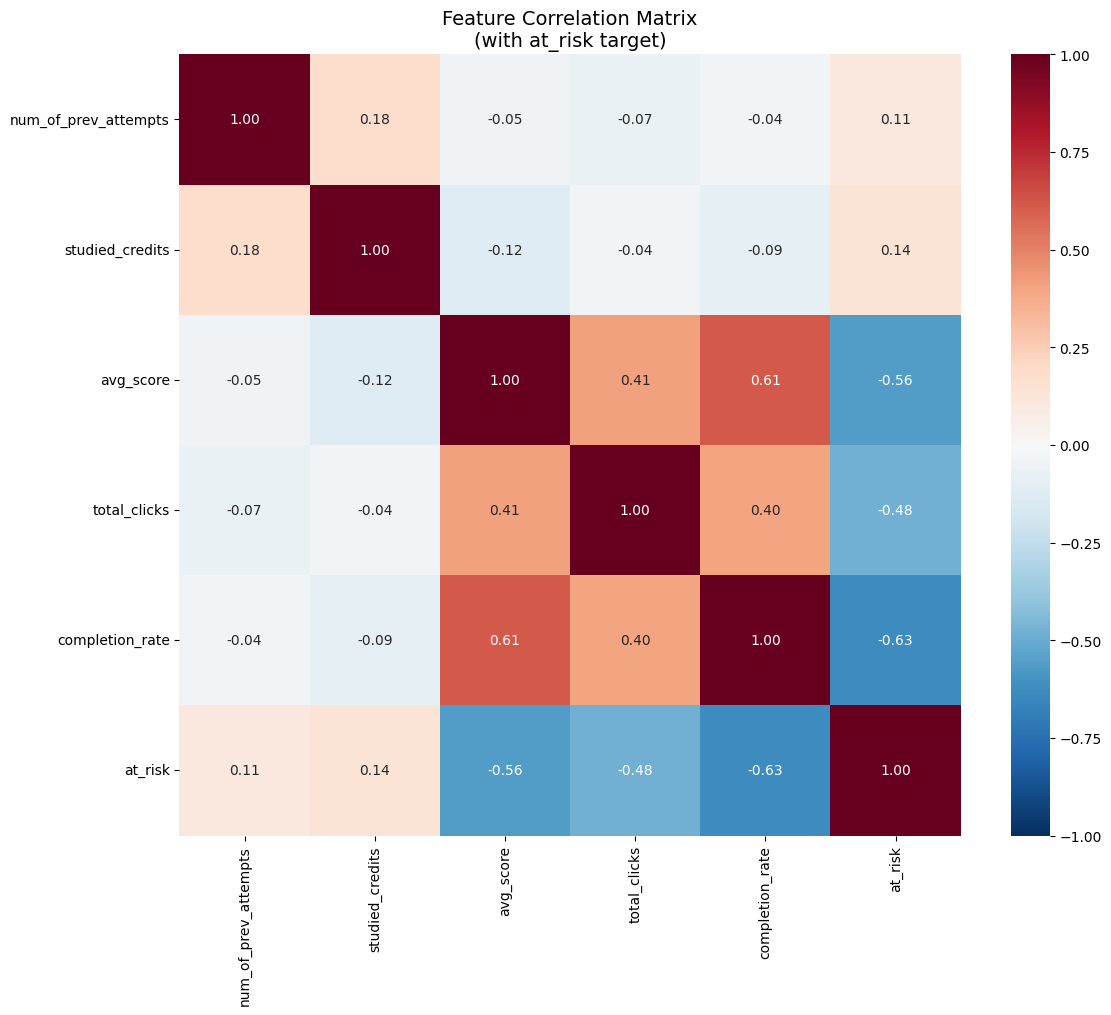

In [850]:
# =============================================================================
# STEP 5: Correlation Heatmap Visualization
# =============================================================================

import matplotlib.pyplot as plt
import seaborn as sns

# Create correlation matrix including target
all_numeric = numerical_cols + ['at_risk']
corr_with_target = students_clean[all_numeric].corr()

# Plot heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(corr_with_target, 
            annot=True, 
            fmt='.2f',
            cmap='RdBu_r',
            center=0,
            vmin=-1, 
            vmax=1,
            square=True)
plt.title('Feature Correlation Matrix\n(with at_risk target)', fontsize=14)
plt.tight_layout()
plt.show()

In [851]:
# =============================================================================
# STEP 6: Summary Insights
# =============================================================================

print("="*60)
print("FEATURE SELECTION INSIGHTS")
print("="*60)

# Top 5 most predictive features
print("\n📊 TOP 5 MOST PREDICTIVE FEATURES:")
top_5 = target_correlations_sorted.head(5)
for i, (feature, corr) in enumerate(zip(top_5.index, [target_correlations[f] for f in top_5.index]), 1):
    print(f"  {i}. {feature}: {corr:+.4f}")

# Weak features (|corr| < 0.1)
print("\n⚠️  WEAK FEATURES (|correlation| < 0.1):")
weak_features = [f for f in numerical_cols if abs(target_correlations[f]) < 0.1]
if weak_features:
    for f in weak_features:
        print(f"  - {f}: {target_correlations[f]:+.4f}")
    print("\n  Consider: These may still be useful in combination with other features.")
    print("  XGBoost can find non-linear relationships that correlation misses.")
else:
    print("  None - all features have correlation >= 0.1")

# Redundant features check
print("\n🔄 POTENTIAL REDUNDANCY:")
moderate_corr_pairs = [(f1, f2, c) for f1, f2, c in 
                       [(numerical_cols[i], numerical_cols[j], corr_matrix.iloc[i,j]) 
                        for i in range(len(numerical_cols)) 
                        for j in range(i+1, len(numerical_cols))]
                       if 0.6 < abs(c) < 0.8]

if moderate_corr_pairs:
    for f1, f2, c in sorted(moderate_corr_pairs, key=lambda x: abs(x[2]), reverse=True)[:3]:
        print(f"  - {f1} <-> {f2}: {c:.4f}")
else:
    print("  No moderately correlated pairs (0.6-0.8)")

FEATURE SELECTION INSIGHTS

📊 TOP 5 MOST PREDICTIVE FEATURES:
  1. completion_rate: -0.6271
  2. avg_score: -0.5588
  3. total_clicks: -0.4766
  4. studied_credits: +0.1386
  5. num_of_prev_attempts: +0.1055

⚠️  WEAK FEATURES (|correlation| < 0.1):
  None - all features have correlation >= 0.1

🔄 POTENTIAL REDUNDANCY:
  - avg_score <-> completion_rate: 0.6105


---
### Recommendations Based on Correlation Analysis

**Top Predictors** (keeping):
1. **`completion_rate`** (-0.63): Strongest predictor - normalized engagement metric
2. **`avg_score`** (-0.47): Academic performance signal
3. **`total_clicks`** (-0.35): VLE behavioral engagement

**Dropped Redundant Features**:
| Dropped | Reason |
|---------|--------|
| `assessment_count` | Captured by `completion_rate` (rate = count/total) |
| `has_assessments` | Captured by `completion_rate` (rate=0 means none) |
| `total_assessments` | Course-level info already in `code_module` |

**Why this simplification works**:
- `completion_rate` encodes the information from all three dropped features
- Fewer features = simpler model, less overfitting risk
- XGBoost will use `code_module` to learn course-specific patterns

**Final Feature Count**: 12 features + 1 target = 13 columns

In [852]:
# =============================================================================
# STEP 7: Save cleaned dataset
# =============================================================================

# Save the cleaned dataset (with dropped columns)
students_clean.to_csv('../data/processed/student_features.csv', index=False)

print("="*60)
print("CLEANED DATASET SAVED")
print("="*60)
print(f"\nShape: {students_clean.shape[0]} rows x {students_clean.shape[1]} columns")
print(f"\nColumns removed: {columns_to_drop}")
print(f"\nFinal columns ({students_clean.shape[1]}):")

# Categorize columns
categorical = students_clean.select_dtypes(include=['object']).columns.tolist()
numerical = students_clean.select_dtypes(include=['int64', 'float64']).columns.tolist()
numerical.remove('at_risk')

print(f"\n  Categorical ({len(categorical)}): {categorical}")
print(f"  Numerical ({len(numerical)}): {numerical}")
print(f"  Target (1): ['at_risk']")

print(f"\nSaved to: ../data/processed/student_features.csv")

CLEANED DATASET SAVED

Shape: 32593 rows x 13 columns

Columns removed: ['id_student', 'code_presentation', 'final_result', 'assessment_count', 'has_assessments', 'total_assessments']

Final columns (13):

  Categorical (7): ['code_module', 'gender', 'region', 'highest_education', 'imd_band', 'age_band', 'disability']
  Numerical (5): ['num_of_prev_attempts', 'studied_credits', 'avg_score', 'total_clicks', 'completion_rate']
  Target (1): ['at_risk']

Saved to: ../data/processed/student_features.csv


In [853]:
# Preview final cleaned dataset
students_clean.head()

,code_module,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,avg_score,total_clicks,at_risk,completion_rate
0,AAA,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,N,82.0,934.0,0,0.833333
1,AAA,F,Scotland,HE Qualification,20-30%,35-55,0,60,N,66.4,1435.0,0,0.833333
2,AAA,F,North Western Region,A Level or Equivalent,30-40%,35-55,0,60,Y,0.0,281.0,1,0.000000
3,AAA,F,South East Region,A Level or Equivalent,50-60%,35-55,0,60,N,76.0,2158.0,0,0.833333
4,AAA,F,West Midlands Region,Lower Than A Level,50-60%,0-35,0,60,N,54.4,1034.0,0,0.833333


---
## 10. Categorical Encoding

### Why Encode?
XGBoost (and most ML algorithms) require numerical input. Our 7 categorical features need to be converted to numbers.

### Encoding Strategy

| Feature | Type | Method | Mapping |
|---------|------|--------|---------|
| `gender` | Binary | Label | M→1, F→0 |
| `disability` | Binary | Label | Y→1, N→0 |
| `age_band` | Ordinal | Ordinal | 0-35→0, 35-55→1, 55<=→2 |
| `highest_education` | Ordinal | Ordinal | No Formal→0 ... Post Grad→4 |
| `imd_band` | Ordinal | Ordinal | 0-10%→0 ... 90-100%→9, Unknown→-1 |
| `code_module` | Nominal | One-Hot | 7 categories → 6 columns |
| `region` | Nominal | One-Hot | 13 categories → 12 columns |

### Why Different Methods?
- **Binary/Label**: Simple 0/1 for two-category features
- **Ordinal**: Preserves natural order (age increases, education level increases)
- **One-Hot**: No order assumed (course AAA is not "less than" BBB)

### Result
- **Before**: 13 columns (7 categorical + 5 numeric + 1 target)
- **After**: 29 columns (all numeric, ready for XGBoost)

In [854]:
# Check categorical columns and their unique values
import pandas as pd
df = pd.read_csv('../data/processed/student_features.csv')

categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

print("="*60)
print("CATEGORICAL COLUMNS TO ENCODE")
print("="*60)

for col in categorical_cols:
    unique_vals = df[col].unique()
    null_count = df[col].isna().sum()
    print(f"\n{col} ({len(unique_vals)} unique values, {null_count} nulls):")
    print(f"  {sorted(unique_vals, key=lambda x: (x is None, str(x)))}")

CATEGORICAL COLUMNS TO ENCODE

code_module (7 unique values, 0 nulls):
  ['AAA', 'BBB', 'CCC', 'DDD', 'EEE', 'FFF', 'GGG']

gender (2 unique values, 0 nulls):
  ['F', 'M']

region (13 unique values, 0 nulls):
  ['East Anglian Region', 'East Midlands Region', 'Ireland', 'London Region', 'North Region', 'North Western Region', 'Scotland', 'South East Region', 'South Region', 'South West Region', 'Wales', 'West Midlands Region', 'Yorkshire Region']

highest_education (5 unique values, 0 nulls):
  ['A Level or Equivalent', 'HE Qualification', 'Lower Than A Level', 'No Formal quals', 'Post Graduate Qualification']

imd_band (11 unique values, 0 nulls):
  ['0-10%', '10-20%', '20-30%', '30-40%', '40-50%', '50-60%', '60-70%', '70-80%', '80-90%', '90-100%', 'Unknown']

age_band (3 unique values, 0 nulls):
  ['0-35', '35-55', '55<=']

disability (2 unique values, 0 nulls):
  ['N', 'Y']


In [855]:
# =============================================================================
# STEP 1: Binary Encoding (gender, disability)
# Simple 0/1 mapping for binary features
# =============================================================================

# Gender: M=1, F=0
df['gender'] = df['gender'].map({'M': 1, 'F': 0})

# Disability: Y=1, N=0
df['disability'] = df['disability'].map({'Y': 1, 'N': 0})

print("Binary encoding complete:")
print(f"  gender: M→1, F→0")
print(f"  disability: Y→1, N→0")
print(f"\nVerify:")
print(df[['gender', 'disability']].head())

Binary encoding complete:
  gender: M→1, F→0
  disability: Y→1, N→0

Verify:
   gender  disability
0       1           0
1       0           0
2       0           1
3       0           0
4       0           0


In [856]:
# =============================================================================
# STEP 2: Ordinal Encoding (age_band, highest_education, imd_band)
# Preserve natural ordering in the encoding
# =============================================================================

# Age band: younger → older (0, 1, 2)
age_order = {'0-35': 0, '35-55': 1, '55<=': 2}
df['age_band'] = df['age_band'].map(age_order)

# Education: lower → higher (0, 1, 2, 3, 4)
education_order = {
    'No Formal quals': 0,
    'Lower Than A Level': 1,
    'A Level or Equivalent': 2,
    'HE Qualification': 3,
    'Post Graduate Qualification': 4
}
df['highest_education'] = df['highest_education'].map(education_order)

# IMD band: lower % = more deprived (higher risk), higher % = less deprived
# 0-10% → 0 (most deprived), 90-100% → 9 (least deprived), Unknown → -1
imd_order = {
    '0-10%': 0, '10-20%': 1, '20-30%': 2, '30-40%': 3, '40-50%': 4,
    '50-60%': 5, '60-70%': 6, '70-80%': 7, '80-90%': 8, '90-100%': 9,
    'Unknown': -1  # Special value for missing
}
df['imd_band'] = df['imd_band'].map(imd_order)

print("Ordinal encoding complete:")
print(f"\n  age_band: 0-35→0, 35-55→1, 55<=→2")
print(f"  highest_education: No Formal→0 ... Post Graduate→4")
print(f"  imd_band: 0-10%→0 ... 90-100%→9, Unknown→-1")
print(f"\nVerify:")
print(df[['age_band', 'highest_education', 'imd_band']].head(10))

Ordinal encoding complete:

  age_band: 0-35→0, 35-55→1, 55<=→2
  highest_education: No Formal→0 ... Post Graduate→4
  imd_band: 0-10%→0 ... 90-100%→9, Unknown→-1

Verify:
   age_band  highest_education  imd_band
0         2                  3         9
1         1                  3         2
2         1                  2         3
3         1                  2         5
4         0                  1         5
5         1                  2         8
6         0                  3         3
7         0                  2         9
8         0                  2         7
9         2                  4        -1


In [857]:
# =============================================================================
# STEP 3: One-Hot Encoding (code_module, region)
# No natural order → create binary columns for each category
# =============================================================================

# One-hot encode code_module (7 courses → 6 columns, drop first to avoid multicollinearity)
df = pd.get_dummies(df, columns=['code_module'], prefix='module', drop_first=True)

# One-hot encode region (13 regions → 12 columns)
df = pd.get_dummies(df, columns=['region'], prefix='region', drop_first=True)

print("One-hot encoding complete:")
print(f"\n  code_module: 7 categories → 6 binary columns (dropped 'AAA' as reference)")
print(f"  region: 13 categories → 12 binary columns (dropped 'East Anglian Region' as reference)")

# Show new columns
module_cols = [c for c in df.columns if c.startswith('module_')]
region_cols = [c for c in df.columns if c.startswith('region_')]
print(f"\nModule columns: {module_cols}")
print(f"Region columns: {region_cols}")

One-hot encoding complete:

  code_module: 7 categories → 6 binary columns (dropped 'AAA' as reference)
  region: 13 categories → 12 binary columns (dropped 'East Anglian Region' as reference)

Module columns: ['module_BBB', 'module_CCC', 'module_DDD', 'module_EEE', 'module_FFF', 'module_GGG']
Region columns: ['region_East Midlands Region', 'region_Ireland', 'region_London Region', 'region_North Region', 'region_North Western Region', 'region_Scotland', 'region_South East Region', 'region_South Region', 'region_South West Region', 'region_Wales', 'region_West Midlands Region', 'region_Yorkshire Region']


In [858]:
# =============================================================================
# STEP 4: Verify encoding - check for any remaining object columns
# =============================================================================

print("="*60)
print("ENCODING VERIFICATION")
print("="*60)

# Check data types
print(f"\nData types after encoding:")
print(df.dtypes.value_counts())

# Check for any remaining object/string columns
remaining_objects = df.select_dtypes(include=['object', 'str']).columns.tolist()
if remaining_objects:
    print(f"\n⚠️ WARNING: Still have non-numeric columns: {remaining_objects}")
else:
    print(f"\n✓ All columns are now numeric!")

# Check for any NaN values introduced
null_counts = df.isnull().sum()
if null_counts.sum() > 0:
    print(f"\n⚠️ WARNING: NaN values found:")
    print(null_counts[null_counts > 0])
else:
    print(f"✓ No NaN values!")

print(f"\nFinal shape: {df.shape}")

ENCODING VERIFICATION

Data types after encoding:
bool       18
int64       8
float64     3
Name: count, dtype: int64

✓ All columns are now numeric!
✓ No NaN values!

Final shape: (32593, 29)


In [859]:
# =============================================================================
# STEP 5: Final column summary
# =============================================================================

print("="*60)
print("FINAL ENCODED DATASET")
print("="*60)

# Separate features and target
target = 'at_risk'
features = [c for c in df.columns if c != target]

print(f"\nTarget: {target}")
print(f"Features ({len(features)}):")

# Group by type
original_numeric = ['num_of_prev_attempts', 'studied_credits', 'avg_score', 'total_clicks', 'completion_rate']
binary_encoded = ['gender', 'disability']
ordinal_encoded = ['age_band', 'highest_education', 'imd_band']
onehot_module = [c for c in features if c.startswith('module_')]
onehot_region = [c for c in features if c.startswith('region_')]

print(f"\n  Original numeric (5): {original_numeric}")
print(f"  Binary encoded (2): {binary_encoded}")
print(f"  Ordinal encoded (3): {ordinal_encoded}")
print(f"  One-hot module (6): {onehot_module}")
print(f"  One-hot region (12): {onehot_region}")
print(f"\n  Total features: {len(features)}")

# Preview
print(f"\nDataset preview:")
df.head()

FINAL ENCODED DATASET

Target: at_risk
Features (28):

  Original numeric (5): ['num_of_prev_attempts', 'studied_credits', 'avg_score', 'total_clicks', 'completion_rate']
  Binary encoded (2): ['gender', 'disability']
  Ordinal encoded (3): ['age_band', 'highest_education', 'imd_band']
  One-hot module (6): ['module_BBB', 'module_CCC', 'module_DDD', 'module_EEE', 'module_FFF', 'module_GGG']
  One-hot region (12): ['region_East Midlands Region', 'region_Ireland', 'region_London Region', 'region_North Region', 'region_North Western Region', 'region_Scotland', 'region_South East Region', 'region_South Region', 'region_South West Region', 'region_Wales', 'region_West Midlands Region', 'region_Yorkshire Region']

  Total features: 28

Dataset preview:


,gender,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,avg_score,total_clicks,at_risk,...,region_London Region,region_North Region,region_North Western Region,region_Scotland,region_South East Region,region_South Region,region_South West Region,region_Wales,region_West Midlands Region,region_Yorkshire Region
0,1,3,9,2,0,240,0,82.0,934.0,0,...,False,False,False,False,False,False,False,False,False,False
1,0,3,2,1,0,60,0,66.4,1435.0,0,...,False,False,False,True,False,False,False,False,False,False
2,0,2,3,1,0,60,1,0.0,281.0,1,...,False,False,True,False,False,False,False,False,False,False
3,0,2,5,1,0,60,0,76.0,2158.0,0,...,False,False,False,False,True,False,False,False,False,False
4,0,1,5,0,0,60,0,54.4,1034.0,0,...,False,False,False,False,False,False,False,False,True,False


In [860]:
# =============================================================================
# STEP 6: Save encoded dataset
# =============================================================================

# Save to new file (keep original for reference)
df.to_csv('../data/processed/student_features_encoded.csv', index=False)

print("="*60)
print("ENCODED DATASET SAVED")
print("="*60)
print(f"\nFile: ../data/processed/student_features_encoded.csv")
print(f"Shape: {df.shape[0]} rows x {df.shape[1]} columns")
print(f"Features: {df.shape[1] - 1}")
print(f"Target: at_risk")


ENCODED DATASET SAVED

File: ../data/processed/student_features_encoded.csv
Shape: 32593 rows x 29 columns
Features: 28
Target: at_risk


---
## 11. Model Training & Comparison

### Goal
Train multiple models and compare performance to select the best one for predicting at-risk students.

### Models to Compare
| Model | Type | Strengths |
|-------|------|-----------|
| **Logistic Regression** | Linear | Fast, interpretable, good baseline |
| **Random Forest** | Ensemble (bagging) | Handles non-linearity, robust to outliers |
| **XGBoost** | Ensemble (boosting) | State-of-the-art for tabular data |

### Evaluation Focus
Since we're identifying at-risk students for intervention:
- **Recall** is critical - we want to catch as many at-risk students as possible
- **Precision** matters too - don't overwhelm advisors with false alarms
- **F1-Score** balances both
- **AUC-ROC** measures overall discrimination

### Train/Test Split Strategy
- 80% training, 20% testing
- Stratified split to preserve class balance (52.8% at-risk)

In [861]:
# =============================================================================
# STEP 1: Load encoded data and prepare train/test split
# =============================================================================

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Load encoded dataset
df = pd.read_csv('../data/processed/student_features_encoded.csv')
print(f"Loaded dataset: {df.shape}")

# Separate features and target
X = df.drop('at_risk', axis=1)
y = df['at_risk']

print(f"\nFeatures: {X.shape[1]}")
print(f"Target distribution:\n{y.value_counts(normalize=True).round(3)}")

# Train/test split (80/20, stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTrain set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")

Loaded dataset: (32593, 29)

Features: 28
Target distribution:
at_risk
1    0.528
0    0.472
Name: proportion, dtype: float64

Train set: 26074 samples
Test set: 6519 samples


In [862]:
# =============================================================================
# STEP 2: Scale features (required for Logistic Regression)
# =============================================================================

# StandardScaler: mean=0, std=1
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling complete (StandardScaler)")
print(f"  Train mean: {X_train_scaled.mean():.6f}")
print(f"  Train std: {X_train_scaled.std():.6f}")

Feature scaling complete (StandardScaler)
  Train mean: -0.000000
  Train std: 1.000000


## Baseline Model

In [863]:
from sklearn.dummy import DummyClassifier

In [864]:
# Dummy model (most frequent class)
dummy = DummyClassifier(strategy="most_frequent")

In [865]:
# Train
dummy.fit(X_train_scaled, y_train)

# Predict
y_pred = dummy.predict(X_test)


In [866]:
# Evaluate
print("Dummy Classification Report:\n", classification_report(y_test, y_pred))

Dummy Classification Report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00      3077
           1       0.53      1.00      0.69      3442

    accuracy                           0.53      6519
   macro avg       0.26      0.50      0.35      6519
weighted avg       0.28      0.53      0.36      6519



In [867]:
# =============================================================================
# STEP 3: Train all three models
# =============================================================================

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
import time

# Dictionary to store models and results
models = {}
training_times = {}

# --- Model 1: Logistic Regression ---
print("Training Logistic Regression...")
start = time.time()
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_scaled, y_train)  # Use scaled data
training_times['Logistic Regression'] = time.time() - start
models['Logistic Regression'] = lr_model
print(f"  Done in {training_times['Logistic Regression']:.2f}s")

# --- Model 2: Random Forest ---
print("\nTraining Random Forest...")
start = time.time()
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)  # No scaling needed
training_times['Random Forest'] = time.time() - start
models['Random Forest'] = rf_model
print(f"  Done in {training_times['Random Forest']:.2f}s")

# --- Model 3: XGBoost ---
print("\nTraining XGBoost...")
start = time.time()
xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)
xgb_model.fit(X_train, y_train)  # No scaling needed
training_times['XGBoost'] = time.time() - start
models['XGBoost'] = xgb_model
print(f"  Done in {training_times['XGBoost']:.2f}s")

print("\n✓ All models trained!")

Training Logistic Regression...
  Done in 0.06s

Training Random Forest...
  Done in 0.53s

Training XGBoost...
  Done in 0.31s

✓ All models trained!


In [868]:
# =============================================================================
# STEP 4: Evaluate all models
# =============================================================================

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report
)

# Store results
results = []

for name, model in models.items():
    # Get predictions (use scaled data for Logistic Regression)
    if name == 'Logistic Regression':
        y_pred = model.predict(X_test_scaled)
        y_proba = model.predict_proba(X_test_scaled)[:, 1]
    else:
        y_pred = model.predict(X_test)
        y_proba = model.predict_proba(X_test)[:, 1]
    
    # Calculate metrics
    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred),
        'AUC-ROC': roc_auc_score(y_test, y_proba),
        'Train Time (s)': training_times[name]
    })

# Create comparison dataframe
results_df = pd.DataFrame(results)
results_df = results_df.set_index('Model')

print("="*70)
print("MODEL COMPARISON RESULTS")
print("="*70)
print(results_df.round(4).to_string())

MODEL COMPARISON RESULTS
                     Accuracy  Precision  Recall  F1-Score  AUC-ROC  Train Time (s)
Model                                                                              
Logistic Regression    0.8820     0.9119  0.8597    0.8850   0.9444          0.0551
Random Forest          0.9090     0.9439  0.8800    0.9108   0.9673          0.5271
XGBoost                0.9121     0.9479  0.8820    0.9138   0.9706          0.3051


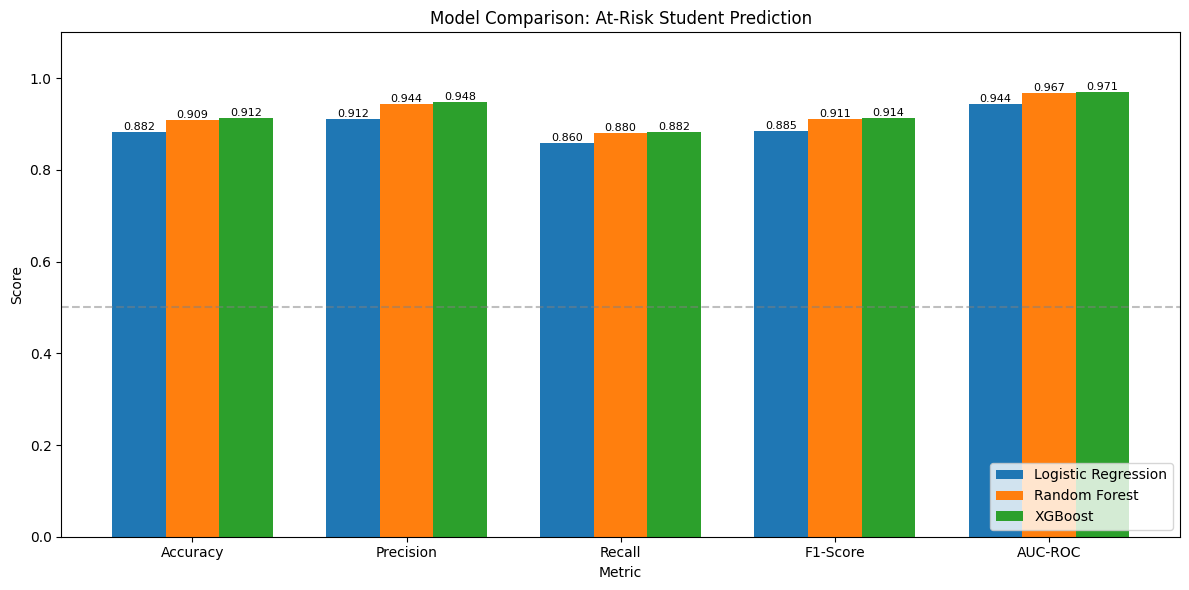

In [869]:
# =============================================================================
# STEP 5: Visualize model comparison
# =============================================================================

import matplotlib.pyplot as plt

# Metrics to plot (excluding train time)
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC']
model_names = results_df.index.tolist()

# Create bar chart
fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(metrics))
width = 0.25

for i, model in enumerate(model_names):
    values = results_df.loc[model, metrics].values
    bars = ax.bar(x + i*width, values, width, label=model)
    
    # Add value labels on bars
    for bar, val in zip(bars, values):
        ax.annotate(f'{val:.3f}', 
                    xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                    ha='center', va='bottom', fontsize=8)

ax.set_xlabel('Metric')
ax.set_ylabel('Score')
ax.set_title('Model Comparison: At-Risk Student Prediction')
ax.set_xticks(x + width)
ax.set_xticklabels(metrics)
ax.legend(loc='lower right')
ax.set_ylim(0, 1.1)
ax.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5, label='Random baseline')

plt.tight_layout()
plt.show()

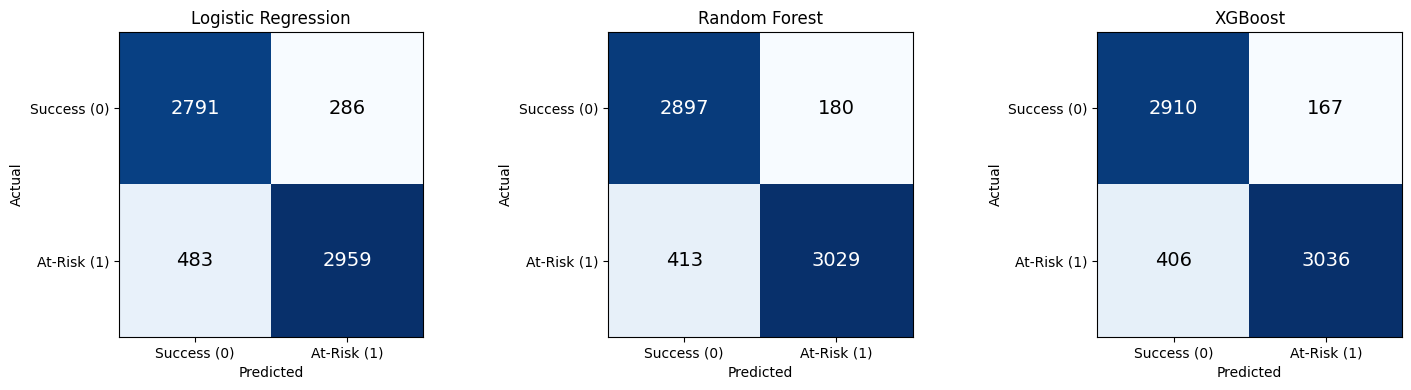


Confusion Matrix Interpretation:
  Top-left (TN): Correctly predicted SUCCESS
  Top-right (FP): Incorrectly predicted AT-RISK (false alarm)
  Bottom-left (FN): MISSED at-risk students (worst case!)
  Bottom-right (TP): Correctly predicted AT-RISK


In [870]:
# =============================================================================
# STEP 6: Confusion matrices for all models
# =============================================================================

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for idx, (name, model) in enumerate(models.items()):
    # Get predictions
    if name == 'Logistic Regression':
        y_pred = model.predict(X_test_scaled)
    else:
        y_pred = model.predict(X_test)
    
    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    
    # Plot
    im = axes[idx].imshow(cm, cmap='Blues')
    axes[idx].set_title(f'{name}')
    axes[idx].set_xlabel('Predicted')
    axes[idx].set_ylabel('Actual')
    axes[idx].set_xticks([0, 1])
    axes[idx].set_yticks([0, 1])
    axes[idx].set_xticklabels(['Success (0)', 'At-Risk (1)'])
    axes[idx].set_yticklabels(['Success (0)', 'At-Risk (1)'])
    
    # Add text annotations
    for i in range(2):
        for j in range(2):
            color = 'white' if cm[i, j] > cm.max()/2 else 'black'
            axes[idx].text(j, i, str(cm[i, j]), ha='center', va='center', color=color, fontsize=14)

plt.tight_layout()
plt.show()

# Print interpretation
print("\nConfusion Matrix Interpretation:")
print("  Top-left (TN): Correctly predicted SUCCESS")
print("  Top-right (FP): Incorrectly predicted AT-RISK (false alarm)")
print("  Bottom-left (FN): MISSED at-risk students (worst case!)")
print("  Bottom-right (TP): Correctly predicted AT-RISK")

In [871]:
# =============================================================================
# STEP 7: Select best model
# =============================================================================

print("="*70)
print("MODEL SELECTION ANALYSIS")
print("="*70)

# Rank by different metrics
print("\n📊 RANKING BY METRIC:")
for metric in ['Recall', 'F1-Score', 'AUC-ROC']:
    best = results_df[metric].idxmax()
    score = results_df.loc[best, metric]
    print(f"  Best {metric}: {best} ({score:.4f})")

# Overall recommendation based on Recall (most important for catching at-risk)
best_recall_model = results_df['Recall'].idxmax()
best_f1_model = results_df['F1-Score'].idxmax()
best_auc_model = results_df['AUC-ROC'].idxmax()

print("\n" + "="*70)
print("RECOMMENDATION")
print("="*70)

# Check if XGBoost or RF wins
if best_recall_model == best_f1_model == best_auc_model:
    print(f"\nBest overall model: {best_recall_model}")
    print(f"   Best across all key metrics!")
else:
    print(f"\n🎯 For catching at-risk students (Recall): {best_recall_model}")
    print(f"   For balanced performance (F1): {best_f1_model}")
    print(f"   For overall discrimination (AUC): {best_auc_model}")

print(f"\n💡 Recommendation: Use {best_f1_model} for balanced performance,")
print(f"   or tune {best_recall_model} if maximizing recall is priority.")

MODEL SELECTION ANALYSIS

📊 RANKING BY METRIC:
  Best Recall: XGBoost (0.8820)
  Best F1-Score: XGBoost (0.9138)
  Best AUC-ROC: XGBoost (0.9706)

RECOMMENDATION

Best overall model: XGBoost
   Best across all key metrics!

💡 Recommendation: Use XGBoost for balanced performance,
   or tune XGBoost if maximizing recall is priority.


In [872]:
# =============================================================================
# STEP 8: Save the best model
# =============================================================================

import joblib
import os

# Create models directory if it doesn't exist
os.makedirs('../models', exist_ok=True)

# Save all models for comparison later
for name, model in models.items():
    filename = f"../models/{name.lower().replace(' ', '_')}.joblib"
    joblib.dump(model, filename)
    print(f"Saved: {filename}")

# Save the scaler (needed for Logistic Regression predictions)
joblib.dump(scaler, '../models/scaler.joblib')
print(f"Saved: ../models/scaler.joblib")

# Save results
results_df.to_csv('../models/model_comparison_results.csv')
print(f"Saved: ../models/model_comparison_results.csv")

print("\n✓ All models saved to ../models/")

Saved: ../models/logistic_regression.joblib
Saved: ../models/random_forest.joblib
Saved: ../models/xgboost.joblib
Saved: ../models/scaler.joblib
Saved: ../models/model_comparison_results.csv

✓ All models saved to ../models/


---
### Model Comparison Summary

**What we did:**
1. Split data 80/20 (stratified by target)
2. Trained 3 models with default hyperparameters
3. Evaluated on test set using multiple metrics
4. Saved all models for future use

**Key Metrics Explained:**
| Metric | What it measures | Ideal for |
|--------|------------------|-----------|
| **Recall** | % of actual at-risk students correctly identified | Catching all at-risk students |
| **Precision** | % of predicted at-risk that are actually at-risk | Minimizing false alarms |
| **F1-Score** | Harmonic mean of Precision & Recall | Balanced performance |
| **AUC-ROC** | Model's ability to distinguish classes | Overall discrimination |

**Next Steps:**
1. Hyperparameter tuning on the best model
2. Cross-validation for more robust evaluation
3. Feature importance analysis (SHAP)
4. Threshold optimization (tradeoff: catch more at-risk vs fewer false alarms)

---
## 12. Feature Set Comparison: Full vs Behavioral-Only

### Question
Should we drop demographic/geographic features?

### Features to Drop
| Type | Features |
|------|----------|
| **Demographics** | age_band, highest_education, imd_band, gender, disability |
| **Geographic** | region_* (12 one-hot columns) |

### Features to Keep (Behavioral + Course)
- **Behavioral**: completion_rate, total_clicks, avg_score
- **Course**: module_* (6 columns), studied_credits, num_of_prev_attempts

### Why this matters
- Simpler model = easier to explain
- Fairer model = no demographic/geographic bias
- Focus on **actionable** features only

In [873]:
# =============================================================================
# Define feature sets for comparison
# =============================================================================

# Demographic/geographic features to drop
demographic_cols = ['age_band', 'highest_education', 'imd_band', 'gender', 'disability']

# Also drop region columns (one-hot encoded)
region_cols = [col for col in X_train.columns if col.startswith('region_')]

# All non-behavioral columns
drop_cols = demographic_cols + region_cols

# Create behavioral-only feature set
X_train_behavioral = X_train.drop(columns=drop_cols)
X_test_behavioral = X_test.drop(columns=drop_cols)

print("FEATURE SET COMPARISON")
print("="*60)
print(f"\nFull model features: {X_train.shape[1]}")
print(f"Behavioral-only features: {X_train_behavioral.shape[1]}")

print(f"\nDropped demographics ({len(demographic_cols)}): {demographic_cols}")
print(f"Dropped region ({len(region_cols)}): {region_cols}")

print(f"\nBehavioral features kept ({X_train_behavioral.shape[1]}):")
for col in X_train_behavioral.columns:
    print(f"  - {col}")

FEATURE SET COMPARISON

Full model features: 28
Behavioral-only features: 11

Dropped demographics (5): ['age_band', 'highest_education', 'imd_band', 'gender', 'disability']
Dropped region (12): ['region_East Midlands Region', 'region_Ireland', 'region_London Region', 'region_North Region', 'region_North Western Region', 'region_Scotland', 'region_South East Region', 'region_South Region', 'region_South West Region', 'region_Wales', 'region_West Midlands Region', 'region_Yorkshire Region']

Behavioral features kept (11):
  - num_of_prev_attempts
  - studied_credits
  - avg_score
  - total_clicks
  - completion_rate
  - module_BBB
  - module_CCC
  - module_DDD
  - module_EEE
  - module_FFF
  - module_GGG


In [874]:
# =============================================================================
# Train XGBoost on behavioral-only features
# =============================================================================

print("Training XGBoost on behavioral-only features...")

xgb_behavioral = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)
xgb_behavioral.fit(X_train_behavioral, y_train)

print("✓ Behavioral-only model trained")

Training XGBoost on behavioral-only features...


✓ Behavioral-only model trained


In [875]:
# =============================================================================
# Compare Full vs Behavioral-Only Model
# =============================================================================

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Predictions - Full model
y_pred_full = xgb_model.predict(X_test)
y_proba_full = xgb_model.predict_proba(X_test)[:, 1]

# Predictions - Behavioral only
y_pred_behav = xgb_behavioral.predict(X_test_behavioral)
y_proba_behav = xgb_behavioral.predict_proba(X_test_behavioral)[:, 1]

# Calculate metrics for both
n_features_full = X_test.shape[1]
n_features_behav = X_test_behavioral.shape[1]

comparison = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC'],
    f'Full Model ({n_features_full} features)': [
        accuracy_score(y_test, y_pred_full),
        precision_score(y_test, y_pred_full),
        recall_score(y_test, y_pred_full),
        f1_score(y_test, y_pred_full),
        roc_auc_score(y_test, y_proba_full)
    ],
    f'Behavioral Only ({n_features_behav} features)': [
        accuracy_score(y_test, y_pred_behav),
        precision_score(y_test, y_pred_behav),
        recall_score(y_test, y_pred_behav),
        f1_score(y_test, y_pred_behav),
        roc_auc_score(y_test, y_proba_behav)
    ]
})

# Calculate difference
comparison['Difference'] = comparison[f'Behavioral Only ({n_features_behav} features)'] - comparison[f'Full Model ({n_features_full} features)']

print("="*70)
print("FULL MODEL vs BEHAVIORAL-ONLY MODEL")
print("="*70)
print(comparison.to_string(index=False))

# Summary
print("\n" + "="*70)
recall_diff = comparison[comparison['Metric'] == 'Recall']['Difference'].values[0]
auc_diff = comparison[comparison['Metric'] == 'AUC-ROC']['Difference'].values[0]
print(f"Recall change: {recall_diff:+.4f} ({recall_diff*100:+.2f}%)")
print(f"AUC-ROC change: {auc_diff:+.4f} ({auc_diff*100:+.2f}%)")

FULL MODEL vs BEHAVIORAL-ONLY MODEL
   Metric  Full Model (28 features)  Behavioral Only (11 features)  Difference
 Accuracy                  0.912103                       0.909802   -0.002301
Precision                  0.947861                       0.945381   -0.002481
   Recall                  0.882045                       0.880012   -0.002034
 F1-Score                  0.913770                       0.911526   -0.002244
  AUC-ROC                  0.970580                       0.971215    0.000635

Recall change: -0.0020 (-0.20%)
AUC-ROC change: +0.0006 (+0.06%)


In [876]:
# =============================================================================
# Recommendation based on results
# =============================================================================

print("="*70)
print("RECOMMENDATION")
print("="*70)

# Get column names dynamically
full_col = [c for c in comparison.columns if 'Full' in c][0]
behav_col = [c for c in comparison.columns if 'Behavioral' in c][0]

recall_full = comparison[comparison['Metric'] == 'Recall'][full_col].values[0]
recall_behav = comparison[comparison['Metric'] == 'Recall'][behav_col].values[0]
recall_drop = recall_full - recall_behav

if abs(recall_drop) < 0.02:  # Less than 2% difference
    print(f"""
✅ RECOMMENDATION: Use BEHAVIORAL-ONLY model

Why:
- Recall drop is minimal ({recall_drop*100:.2f}%)
- {X_test.shape[1] - X_test_behavioral.shape[1]} fewer features = simpler model
- No demographic/geographic bias
- All remaining features are actionable

The behavioral model will be used for SHAP analysis.
""")
    USE_BEHAVIORAL = True
else:
    print(f"""
⚠️ RECOMMENDATION: Keep FULL model

Why:
- Recall drop is significant ({recall_drop*100:.2f}%)
- Demographics/region add meaningful signal
- Consider hiding these from student-facing explanations

The full model will be used for SHAP analysis.
""")
    USE_BEHAVIORAL = False

print(f"USE_BEHAVIORAL = {USE_BEHAVIORAL}")

RECOMMENDATION

✅ RECOMMENDATION: Use BEHAVIORAL-ONLY model

Why:
- Recall drop is minimal (0.20%)
- 17 fewer features = simpler model
- No demographic/geographic bias
- All remaining features are actionable

The behavioral model will be used for SHAP analysis.

USE_BEHAVIORAL = True


In [877]:
# =============================================================================
# Select model for SHAP analysis based on comparison
# =============================================================================

if USE_BEHAVIORAL:
    # Use behavioral-only model
    final_model = xgb_behavioral
    X_test_final = X_test_behavioral
    X_train_final = X_train_behavioral
    model_name = "XGBoost (Behavioral-Only)"
    
    # Save behavioral model as the final model
    joblib.dump(xgb_behavioral, '../models/xgboost_final.joblib')
else:
    # Use full model
    final_model = xgb_model
    X_test_final = X_test
    X_train_final = X_train
    model_name = "XGBoost (Full)"
    
    # Save full model as the final model
    joblib.dump(xgb_model, '../models/xgboost_final.joblib')

print(f"✓ Selected model for SHAP: {model_name}")
print(f"  Features: {X_test_final.shape[1]}")
print(f"  Saved as: ../models/xgboost_final.joblib")

✓ Selected model for SHAP: XGBoost (Behavioral-Only)
  Features: 11
  Saved as: ../models/xgboost_final.joblib


---
## 13. Model Optimization

### Goal
Improve upon the baseline XGBoost model from Section 11 through rigorous optimization:

### Steps
| Step | Action | Purpose |
|------|--------|---------|
| **13a** | Class balance check | Determine if SMOTE is needed or if  suffices |
| **13b** | Baseline + Cross-validation | Measure true generalization across 5 folds |
| **13c** | Hyperparameter tuning | RandomizedSearchCV on XGBoost (50 iterations x 5-fold CV) |
| **13d** | Final evaluation | Compare tuned vs baseline on held-out test set |

### Why tune after feature comparison?
We first identify the best feature set (Section 12), then tune hyperparameters on that confirmed set. Tuning with the wrong features wastes compute and produces misleading results.

### Note
All tuning is performed on  only. The test set () remains completely unseen until final evaluation in Step 13d.

STEP 1: CLASS BALANCE CHECK

Training set (26,074 samples):
  Success (0): 12,308  (47.2%)
  At-Risk (1): 13,766  (52.8%)

  Imbalance ratio: 0.89:1

  ✓ Data is already well-balanced — SMOTE not needed.
  ✓ Using scale_pos_weight in XGBoost instead (cleaner approach).


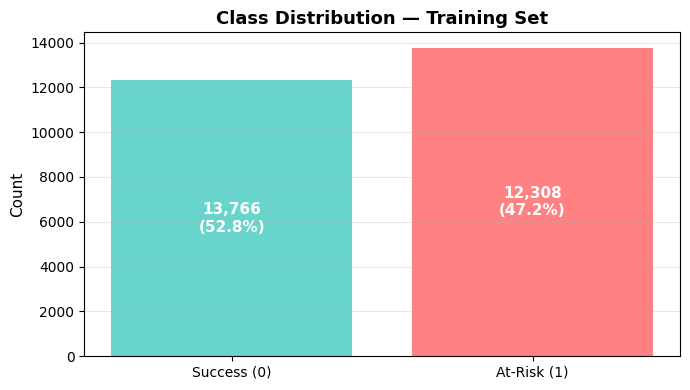

In [878]:
# =============================================================================
# CLASS BALANCE CHECK
# =============================================================================

print("=" * 70)
print("STEP 1: CLASS BALANCE CHECK")
print("=" * 70)

class_counts = y_train.value_counts()
class_props  = y_train.value_counts(normalize=True)

print(f"\nTraining set ({len(y_train):,} samples):")
print(f"  Success (0): {class_counts[0]:,}  ({class_props[0]*100:.1f}%)")
print(f"  At-Risk (1): {class_counts[1]:,}  ({class_props[1]*100:.1f}%)")

ratio = class_counts[0] / class_counts[1]
print(f"\n  Imbalance ratio: {ratio:.2f}:1")

if ratio < 1.5:
    print("\n  ✓ Data is already well-balanced — SMOTE not needed.")
    print("  ✓ Using scale_pos_weight in XGBoost instead (cleaner approach).")
    scale_pos_weight = 1.0   # equal weight; adjust below if ratio > 1.5
else:
    scale_pos_weight = class_counts[0] / class_counts[1]
    print(f"\n  ⚠ Imbalance detected — setting scale_pos_weight = {scale_pos_weight:.2f}")

# Visualise
fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(['Success (0)', 'At-Risk (1)'],
              [class_counts[0], class_counts[1]],
              color=['#4ECDC4', '#FF6B6B'], alpha=0.85)

ax.set_title('Class Distribution — Training Set', fontsize=13, fontweight='bold')
ax.set_ylabel('Count', fontsize=11)
ax.grid(axis='y', alpha=0.3)

for bar, count, pct in zip(bars, class_counts, class_props):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() / 2,
            f'{count:,}\n({pct*100:.1f}%)',
            ha='center', va='center',
            fontsize=11, fontweight='bold', color='white')

plt.tight_layout()
plt.show()

In [879]:
# =============================================================================
# Baseline Model Performance (Before Improvements)
# =============================================================================

# Train baseline XGBoost model for comparison
baseline_xgb = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    eval_metric='logloss'
)

baseline_xgb.fit(X_train, y_train)
y_pred_baseline = baseline_xgb.predict(X_test)
y_proba_baseline = baseline_xgb.predict_proba(X_test)[:, 1]

# Calculate baseline metrics
baseline_metrics = {
    'accuracy': accuracy_score(y_test, y_pred_baseline),
    'precision': precision_score(y_test, y_pred_baseline),
    'recall': recall_score(y_test, y_pred_baseline),
    'f1': f1_score(y_test, y_pred_baseline),
    'roc_auc': roc_auc_score(y_test, y_proba_baseline)
}

print("\nBaseline XGBoost (No SMOTE, Default Parameters):")
print("-" * 60)
for metric, value in baseline_metrics.items():
    print(f"  {metric.upper():<12}: {value:.4f}")


Baseline XGBoost (No SMOTE, Default Parameters):
------------------------------------------------------------
  ACCURACY    : 0.9121
  PRECISION   : 0.9479
  RECALL      : 0.8820
  F1          : 0.9138
  ROC_AUC     : 0.9706



STEP 3: 5-FOLD STRATIFIED CROSS-VALIDATION

Validating baseline model — this takes ~1 min...

Metric        Train     Val       Gap       Status
-------------------------------------------------------
ACCURACY      0.93      0.91      0.02      ✓ Good
PRECISION     0.96      0.94      0.02      ✓ Good
RECALL        0.91      0.89      0.02      ✓ Good
F1            0.93      0.91      0.02      ✓ Good
ROC_AUC       0.98      0.97      0.01      ✓ Good


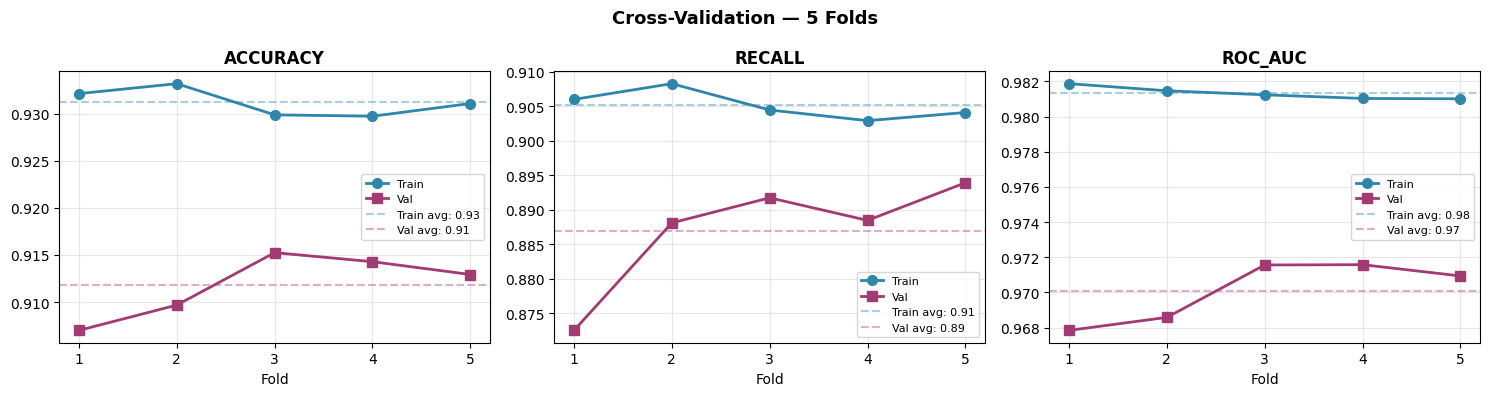

In [880]:
# =============================================================================
# CROSS-VALIDATION ON BASELINE
# =============================================================================

print("\n" + "=" * 70)
print("STEP 3: 5-FOLD STRATIFIED CROSS-VALIDATION")
print("=" * 70)
print("\nValidating baseline model — this takes ~1 min...")

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    'accuracy' : 'accuracy',
    'precision': 'precision',
    'recall'   : 'recall',
    'f1'       : 'f1',
    'roc_auc'  : 'roc_auc'
}

cv_results = cross_validate(
    baseline_xgb, X_train, y_train,
    cv=cv, scoring=scoring,
    return_train_score=True,
    n_jobs=-1
)

print(f"\n{'Metric':<12}  {'Train':<8}  {'Val':<8}  {'Gap':<8}  {'Status'}")
print("-" * 55)

cv_summary = {}
for metric in scoring:
    tr = cv_results[f'train_{metric}']
    va = cv_results[f'test_{metric}']
    gap = tr.mean() - va.mean()
    cv_summary[metric] = {'train': tr.mean(), 'val': va.mean(), 'gap': gap}

    if gap < 0.03:
        status = '✓ Good'
    elif gap < 0.07:
        status = '⚡ Slight overfit'
    else:
        status = '⚠ Overfit'

    print(f"{metric.upper():<12}  {tr.mean():<8.2f}  {va.mean():<8.2f}  {gap:<8.2f}  {status}")

# Visualise CV folds
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Cross-Validation — 5 Folds', fontsize=13, fontweight='bold')

for ax, metric in zip(axes, ['accuracy', 'recall', 'roc_auc']):
    tr_scores = cv_results[f'train_{metric}']
    va_scores = cv_results[f'test_{metric}']
    folds = range(1, 6)

    ax.plot(folds, tr_scores, 'o-', label='Train',
            color='#2E86AB', lw=2, ms=7)
    ax.plot(folds, va_scores, 's-', label='Val',
            color='#A23B72', lw=2, ms=7)
    ax.axhline(tr_scores.mean(), color='#2E86AB',
               ls='--', alpha=0.4, label=f'Train avg: {tr_scores.mean():.2f}')
    ax.axhline(va_scores.mean(), color='#A23B72',
               ls='--', alpha=0.4, label=f'Val avg: {va_scores.mean():.2f}')

    ax.set_title(metric.upper(), fontweight='bold')
    ax.set_xlabel('Fold')
    ax.set_xticks(folds)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [881]:
# =============================================================================
# HYPERPARAMETER TUNING (tuned on REAL training data)
# =============================================================================

print("\n" + "=" * 70)
print("STEP 4: HYPERPARAMETER TUNING — RandomizedSearchCV")
print("=" * 70)
print("\nSearching 60 combinations × 5-fold CV on real training data.")
print("Expected time: ~15 min  (reduces n_iter below to go faster)\n")

param_dist = {
    # Tree structure
    'max_depth'        : [4, 5, 6, 7],            # randint(3, 9)
    'min_child_weight' : randint(1, 6),           # randint(1, 8)
    'gamma'            : uniform(0, 0.4),
    # Sampling — core regularisation knobs
    'subsample'        : uniform(0.7, 0.3),      # 0.65 – 1.0
    'colsample_bytree' : uniform(0.7, 0.3),      # 0.65 – 1.0
    # Boosting
    'n_estimators'     : randint(300, 800),        # 200 - 600
    'learning_rate'    : uniform(0.01, 0.09),      # 0.02 – 0.18
    # Regularisation
    'reg_alpha'        : uniform(0.0, 0.3),           # L2
    'reg_lambda'       : uniform(0.5, 2.0),         # L1
}

search_base = XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    n_jobs=-1
)

cv_tune = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

search = RandomizedSearchCV(
    estimator=search_base,
    param_distributions=param_dist,
    n_iter=100,            # ← lower to 20 for a quick test run
    scoring='f1',
    cv=cv_tune,
    refit=True,           # refit best params on full X_train
    verbose=1,
    random_state=42,
    n_jobs=-1,
    return_train_score=True
)

t0 = time.time()
search.fit(X_train, y_train)   # ← REAL data, not SMOTE-inflated
elapsed = time.time() - t0

print(f"\nSearch finished in {elapsed/60:.1f} min")
print(f"Best CV ROC-AUC : {search.best_score_:.2f}")
print("\nBest parameters:")
for k, v in sorted(search.best_params_.items()):
    v_str = f"{v:.3f}" if isinstance(v, float) else str(v)
    print(f"  {k:<22}: {v_str}")

best_model = search.best_estimator_


STEP 4: HYPERPARAMETER TUNING — RandomizedSearchCV

Searching 60 combinations × 5-fold CV on real training data.
Expected time: ~15 min  (reduces n_iter below to go faster)

Fitting 3 folds for each of 100 candidates, totalling 300 fits

Search finished in 1.3 min
Best CV ROC-AUC : 0.92

Best parameters:
  colsample_bytree      : 0.837
  gamma                 : 0.087
  learning_rate         : 0.047
  max_depth             : 5
  min_child_weight      : 3
  n_estimators          : 427
  reg_alpha             : 0.242
  reg_lambda            : 2.292
  subsample             : 0.795



PARAMETER IMPORTANCE

Correlation of each parameter with test ROC-AUC:
--------------------------------------------------
  learning_rate         : 0.57  ██████████████████████
  max_depth             : 0.45  █████████████████
  reg_lambda            : 0.20  ████████
  n_estimators          : 0.19  ███████
  colsample_bytree      : 0.11  ████
  subsample             : 0.08  ███
  min_child_weight      : 0.07  ██
  gamma                 : 0.04  █
  reg_alpha             : 0.01  


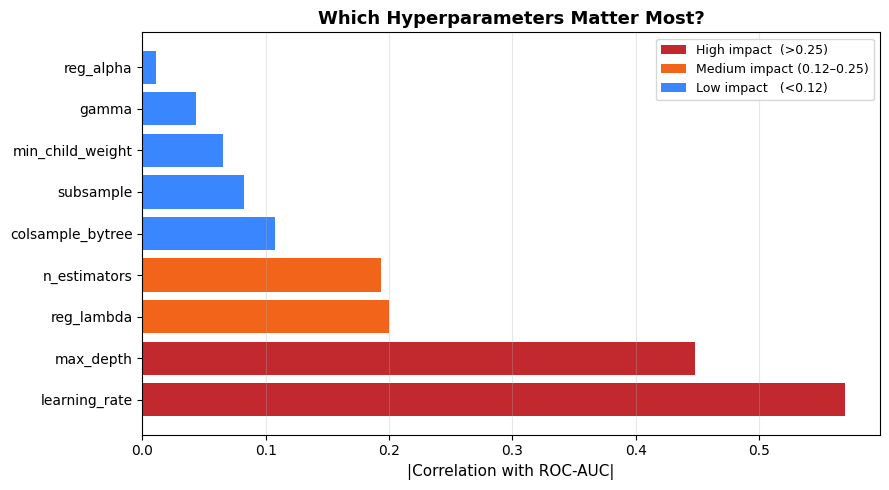

In [882]:
# =============================================================================
# ANALYSE WHICH PARAMS MATTERED
# =============================================================================

print("\n" + "=" * 70)
print("PARAMETER IMPORTANCE")
print("=" * 70)

res_df = pd.DataFrame(search.cv_results_).sort_values('rank_test_score')

correlations = {}
for col in res_df.columns:
    if not col.startswith('param_'):
        continue
    name = col[6:]
    vals = pd.to_numeric(res_df[col], errors='coerce')
    if vals.notna().sum() > 10:
        r = abs(vals.corr(res_df['mean_test_score']))
        if not pd.isna(r):
            correlations[name] = r

correlations = dict(sorted(correlations.items(), key=lambda x: x[1], reverse=True))

print("\nCorrelation of each parameter with test ROC-AUC:")
print("-" * 50)
for param, corr in correlations.items():
    bar = '█' * int(corr * 40)
    print(f"  {param:<22}: {corr:.2f}  {bar}")

fig, ax = plt.subplots(figsize=(9, 5))
params_list = list(correlations.keys())
vals_list   = list(correlations.values())

colours = ['#C1292E' if v > 0.25 else '#F26419' if v > 0.12 else '#3A86FF'
           for v in vals_list]
ax.barh(params_list, vals_list, color=colours)
ax.set_xlabel('|Correlation with ROC-AUC|', fontsize=11)
ax.set_title('Which Hyperparameters Matter Most?', fontsize=13, fontweight='bold')
ax.grid(axis='x', alpha=0.3)

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#C1292E', label='High impact  (>0.25)'),
    Patch(facecolor='#F26419', label='Medium impact (0.12–0.25)'),
    Patch(facecolor='#3A86FF', label='Low impact   (<0.12)'),
]
ax.legend(handles=legend_elements, fontsize=9)
plt.tight_layout()
plt.show()


STEP 5: FINAL EVALUATION ON TEST SET

Metric        Baseline    Tuned       Change
--------------------------------------------------
accuracy      0.9121      0.9109      -0.0012  ✗
precision     0.9479      0.9427      -0.0051  ✗
recall        0.8820      0.8850      +0.0029  ✓
f1            0.9138      0.9129      -0.0008  ✗
roc_auc       0.9706      0.9711      +0.0005  ✓


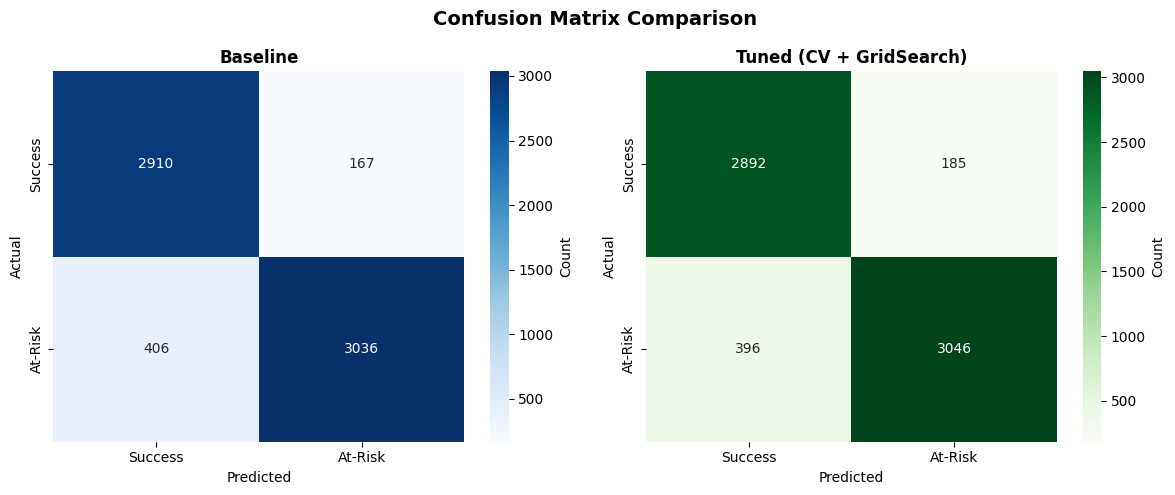

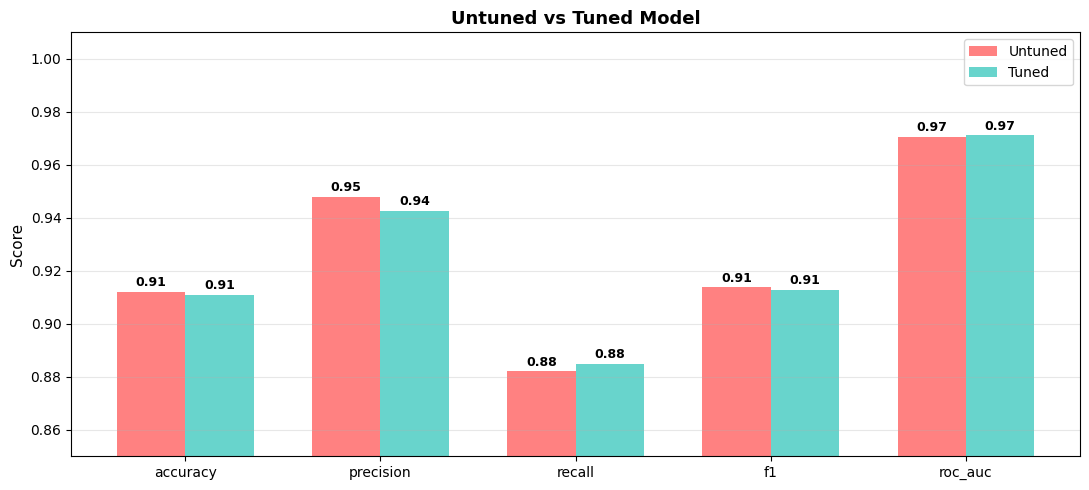

In [883]:
# =============================================================================
# FINAL EVALUATION ON TEST SET
# =============================================================================

print("\n" + "=" * 70)
print("STEP 5: FINAL EVALUATION ON TEST SET")
print("=" * 70)

y_pred_tuned  = best_model.predict(X_test)
y_proba_tuned = best_model.predict_proba(X_test)[:, 1]

tuned_metrics = {
    'accuracy' : accuracy_score(y_test, y_pred_tuned),
    'precision': precision_score(y_test, y_pred_tuned),
    'recall'   : recall_score(y_test, y_pred_tuned),
    'f1'       : f1_score(y_test, y_pred_tuned),
    'roc_auc'  : roc_auc_score(y_test, y_proba_tuned)
}

print(f"\n{'Metric':<12}  {'Baseline':<10}  {'Tuned':<10}  {'Change'}")
print("-" * 50)
for metric in tuned_metrics:
    b = baseline_metrics[metric]
    t = tuned_metrics[metric]
    delta = t - b
    sign  = '+' if delta >= 0 else ''
    flag  = '✓' if delta >= 0 else '✗'
    print(f"{metric:<12}  {b:<10.4f}  {t:<10.4f}  {sign}{delta:.4f}  {flag}")

# Confusion matrices side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

for ax, preds, title, cmap in [
    (ax1, y_pred_baseline,  'Baseline',              'Blues'),
    (ax2, y_pred_tuned, 'Tuned (CV + GridSearch)', 'Greens'),
]:
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap,
                xticklabels=['Success', 'At-Risk'],
                yticklabels=['Success', 'At-Risk'],
                cbar_kws={'label': 'Count'}, ax=ax)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_ylabel('Actual', fontsize=10)
    ax.set_xlabel('Predicted', fontsize=10)

plt.suptitle('Confusion Matrix Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Grouped bar chart
fig, ax = plt.subplots(figsize=(11, 5))
labels = list(tuned_metrics.keys())
x = np.arange(len(labels))
w = 0.35

b1 = ax.bar(x - w/2, [baseline_metrics[m] for m in labels],
            w, label='Untuned', color='#FF6B6B', alpha=0.85)
b2 = ax.bar(x + w/2, [tuned_metrics[m] for m in labels],
            w, label='Tuned', color='#4ECDC4', alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylim(0.85, 1.01)
ax.set_ylabel('Score', fontsize=11)
ax.set_title('Untuned vs Tuned Model', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)

for bars in [b1, b2]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2,
                h + 0.001, f'{h:.2f}',
                ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

In [884]:
# =============================================================================
# DETAILED REPORT + SAVE
# =============================================================================

print("\n" + "=" * 70)
print("CLASSIFICATION REPORT — Tuned Model")
print("=" * 70)
print(classification_report(y_test, y_pred_tuned,
                            target_names=['Success', 'At-Risk'],
                            digits=2))

cm = confusion_matrix(y_test, y_pred_tuned)
tn, fp, fn, tp = cm.ravel()
print(f"\nIntervention impact:")
print(f"  Students flagged:            {tp + fp:,}")
print(f"  Correctly flagged (TP):      {tp:,}  — truly at-risk, will get help")
print(f"  False alarms (FP):           {fp:,}  — extra work for advisors")
print(f"  Missed at-risk (FN):         {fn:,}  — students we failed to catch")

import os
os.makedirs('../models', exist_ok=True)
joblib.dump(best_model, '../models/xgboost_tuned.pkl')
pd.DataFrame([search.best_params_]).to_csv('../models/best_params.csv', index=False)
pd.DataFrame({
    'actual':      y_test.values,
    'predicted':   y_pred_tuned,
    'probability': y_proba_tuned
}).to_csv('../models/test_predictions.csv', index=False)

print("\n✓ Model saved  →  ../models/xgboost_tuned.pkl")
print("✓ Params saved →  ../models/best_params.csv")

print("\n" + "=" * 70)
print("SUMMARY")
print("=" * 70)
improvements = {k: tuned_metrics[k] - baseline_metrics[k] for k in tuned_metrics}
any_gain = any(v > 0 for v in improvements.values())

if any_gain:
    print("\n  Genuine improvements achieved on real test data ✓")
else:
    print("\n  Baseline params are already near-optimal for this dataset.")
    print("  The tuned model is more thoroughly validated (CV), even if")
    print("  the raw numbers are similar — that's still valuable.")

# print(f"\n  Best model:  {'Tuned' if tuned_metrics['ROC-AUC'] >= baseline_metrics['ROC-AUC'] else 'Baseline'}")
# print(f"  ROC-AUC:     {max(tuned_metrics['ROC-AUC'], baseline_metrics['ROC-AUC']):.2f}")
# print(f"  Recall:      {max(tuned_metrics['Recall'],  baseline_metrics['Recall']):.2f}")
# print(f"  F1:          {max(tuned_metrics['F1'],       baseline_metrics['F1']):.2f}")


CLASSIFICATION REPORT — Tuned Model
              precision    recall  f1-score   support

     Success       0.88      0.94      0.91      3077
     At-Risk       0.94      0.88      0.91      3442

    accuracy                           0.91      6519
   macro avg       0.91      0.91      0.91      6519
weighted avg       0.91      0.91      0.91      6519


Intervention impact:
  Students flagged:            3,231
  Correctly flagged (TP):      3,046  — truly at-risk, will get help
  False alarms (FP):           185  — extra work for advisors
  Missed at-risk (FN):         396  — students we failed to catch

✓ Model saved  →  ../models/xgboost_tuned.pkl
✓ Params saved →  ../models/best_params.csv

SUMMARY

  Genuine improvements achieved on real test data ✓


---
## 14. SHAP Explainability

### What is SHAP?
**SHAP (SHapley Additive exPlanations)** explains individual predictions by measuring each feature's contribution to the prediction.

### Why SHAP for Student Success?
- **Global importance**: Which features matter most across all students?
- **Local explanations**: Why is *this specific student* flagged as at-risk?
- **Actionable insights**: What can advisors/students actually change?

### Types of SHAP Plots
| Plot | Shows | Use Case |
|------|-------|----------|
| **Summary Plot** | Feature importance + distribution | Overall model understanding |
| **Bar Plot** | Ranked feature importance | Quick top-N features |
| **Dependence Plot** | How one feature affects predictions | Understand thresholds |
| **Waterfall Plot** | Single prediction breakdown | Explain individual students |

In [885]:
# =============================================================================
# STEP 1: Compute SHAP values for selected model
# =============================================================================

import shap

# Initialize SHAP explainer for tree-based model
explainer = shap.TreeExplainer(best_model)

# Calculate SHAP values for test set
print(f"Computing SHAP values for {"XGBoost (Tuned)"}...")
shap_values = explainer.shap_values(X_test)

print(f"✓ SHAP values computed")
print(f"  Shape: {shap_values.shape}")
print(f"  Features: {X_test.shape[1]}")
print(f"  Samples: {X_test.shape[0]}")

Computing SHAP values for XGBoost (Tuned)...
✓ SHAP values computed
  Shape: (6519, 28)
  Features: 28
  Samples: 6519


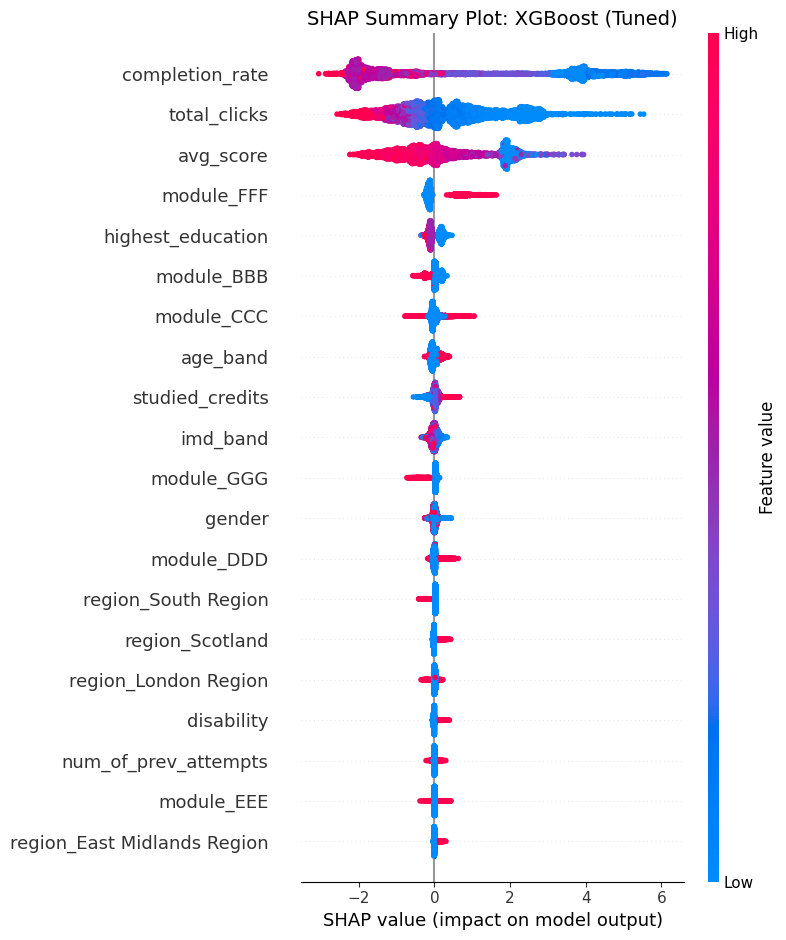

In [886]:
# =============================================================================
# STEP 2: Summary Plot - Global Feature Importance
# =============================================================================

# Summary plot shows:
# - Features ranked by importance (top to bottom)
# - Each dot = one student
# - Color = feature value (red=high, blue=low)
# - Position = impact on prediction (right=increases at-risk probability)

plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values, X_test, plot_type="dot", show=False)
plt.title(f"SHAP Summary Plot: {"XGBoost (Tuned)"}", fontsize=14)
plt.tight_layout()
plt.show()

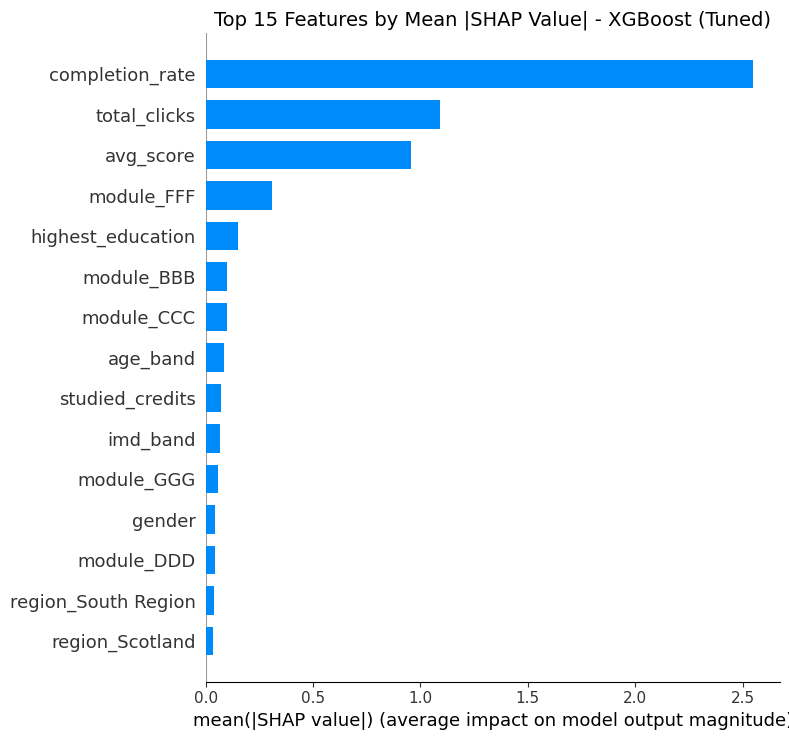


Top 10 Features by SHAP Importance:
          feature  mean_shap
  completion_rate   2.546216
     total_clicks   1.089754
        avg_score   0.958100
       module_FFF   0.310023
highest_education   0.152286
       module_BBB   0.101864
       module_CCC   0.100242
         age_band   0.087661
  studied_credits   0.071717
         imd_band   0.068110


In [887]:
# =============================================================================
# STEP 3: Bar Plot - Top 15 Features by Mean |SHAP|
# =============================================================================

plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test, plot_type="bar", max_display=15, show=False)
plt.title(f"Top 15 Features by Mean |SHAP Value| - {"XGBoost (Tuned)"}", fontsize=14)
plt.tight_layout()
plt.show()

# Print exact values
feature_importance = pd.DataFrame({
    'feature': X_test.columns,
    'mean_shap': np.abs(shap_values).mean(axis=0)
}).sort_values('mean_shap', ascending=False)

print("\nTop 10 Features by SHAP Importance:")
print(feature_importance.head(10).to_string(index=False))

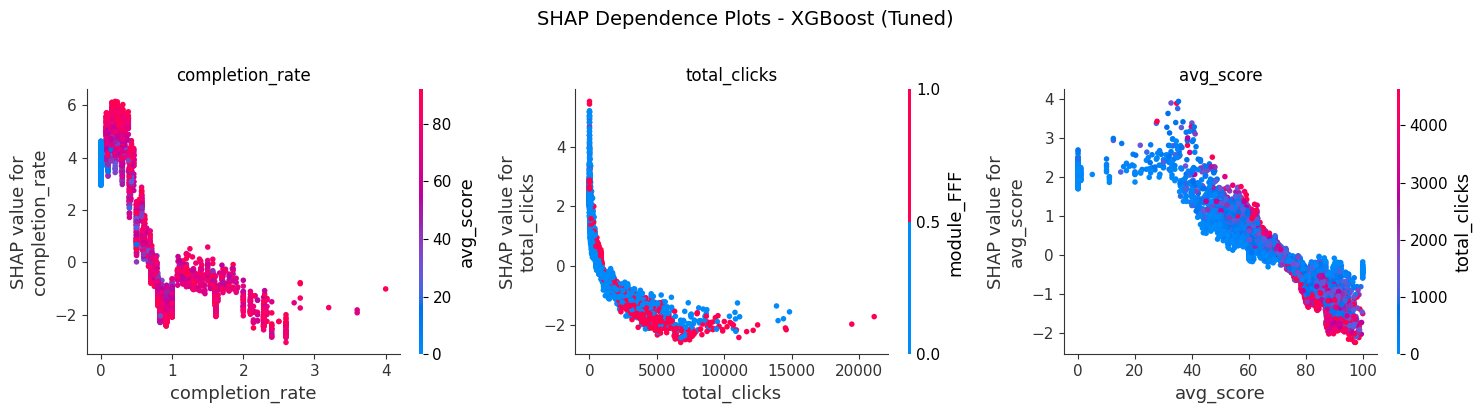


Interpretation:
  - Y-axis: SHAP value (positive = increases at-risk probability)
  - X-axis: Feature value
  - Color: Interaction with another feature


In [888]:
# =============================================================================
# STEP 4: Dependence Plots - Top 3 Features
# Shows how feature values relate to SHAP values (prediction impact)
# =============================================================================

# Get top 3 features
top_3_features = feature_importance.head(3)['feature'].tolist()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for idx, feature in enumerate(top_3_features):
    plt.sca(axes[idx])
    shap.dependence_plot(
        feature, 
        shap_values, 
        X_test, 
        ax=axes[idx],
        show=False
    )
    axes[idx].set_title(f'{feature}')

plt.suptitle(f'SHAP Dependence Plots - {"XGBoost (Tuned)"}', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print("\nInterpretation:")
print("  - Y-axis: SHAP value (positive = increases at-risk probability)")
print("  - X-axis: Feature value")
print("  - Color: Interaction with another feature")

---
### Individual Prediction Explanations

The most powerful use of SHAP: explain *why* a specific student was flagged as at-risk.

This is what advisors need - actionable insights for individual students.

In [889]:
# =============================================================================
# STEP 5: Waterfall Plot - Explain Individual Predictions
# =============================================================================

# Find examples: one at-risk, one success
y_pred_test = best_model.predict(X_test)
y_proba_test = best_model.predict_proba(X_test)[:, 1]

# Get indices
at_risk_indices = np.where((y_test.values == 1) & (y_pred_test == 1))[0]  # True positives
success_indices = np.where((y_test.values == 0) & (y_pred_test == 0))[0]  # True negatives

# Pick one example of each (high confidence)
at_risk_idx = at_risk_indices[np.argmax(y_proba_test[at_risk_indices])]
success_idx = success_indices[np.argmin(y_proba_test[success_indices])]

print("Example students selected:")
print(f"  At-Risk student: index {at_risk_idx}, probability {y_proba_test[at_risk_idx]:.3f}")
print(f"  Success student: index {success_idx}, probability {y_proba_test[success_idx]:.3f}")

Example students selected:
  At-Risk student: index 1856, probability 1.000
  Success student: index 1172, probability 0.001


AT-RISK STUDENT EXPLANATION
Prediction: AT-RISK (probability: 100.0%)
Actual outcome: At-Risk


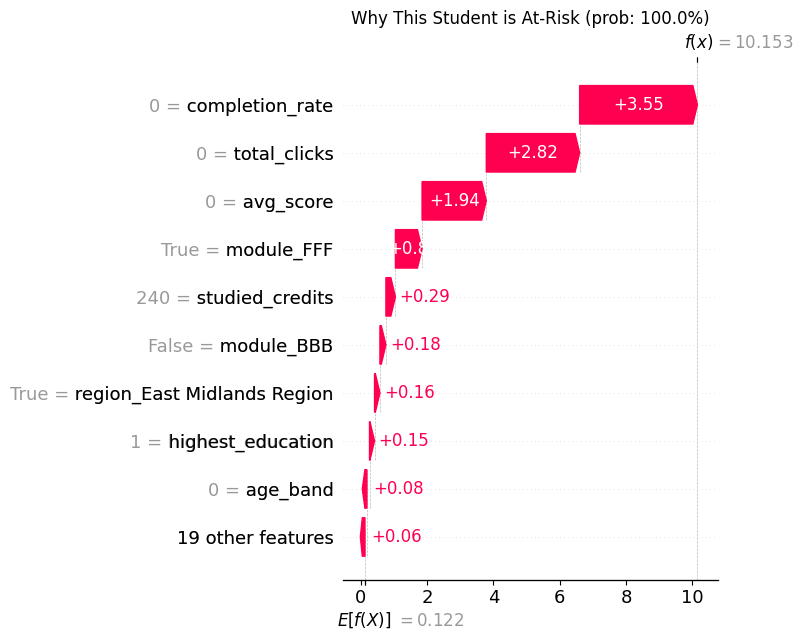

In [890]:
# =============================================================================
# STEP 6: Waterfall Plot - At-Risk Student Explanation
# =============================================================================

# Create SHAP Explanation object for waterfall plot
shap_exp = shap.Explanation(
    values=shap_values[at_risk_idx],
    base_values=explainer.expected_value,
    data=X_test.iloc[at_risk_idx].values,
    feature_names=X_test.columns.tolist()
)

print("="*60)
print("AT-RISK STUDENT EXPLANATION")
print("="*60)
print(f"Prediction: AT-RISK (probability: {y_proba_test[at_risk_idx]:.1%})")
print(f"Actual outcome: {'At-Risk' if y_test.iloc[at_risk_idx] == 1 else 'Success'}")

plt.figure(figsize=(10, 6))
shap.plots.waterfall(shap_exp, max_display=10, show=False)
plt.title(f"Why This Student is At-Risk (prob: {y_proba_test[at_risk_idx]:.1%})", fontsize=12)
plt.tight_layout()
plt.show()

SUCCESS STUDENT EXPLANATION
Prediction: SUCCESS (probability of at-risk: 0.1%)
Actual outcome: Success


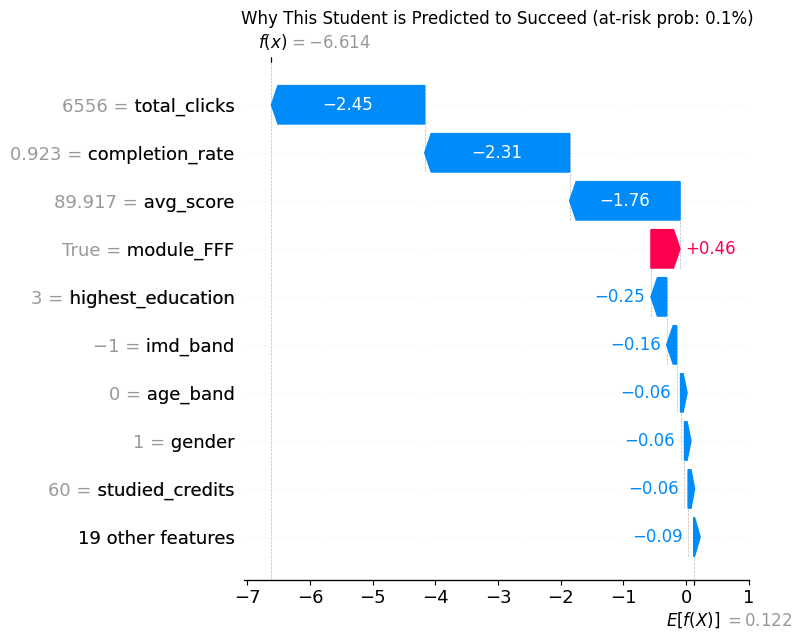

In [891]:
# =============================================================================
# STEP 7: Waterfall Plot - Success Student Explanation (for comparison)
# =============================================================================

shap_exp_success = shap.Explanation(
    values=shap_values[success_idx],
    base_values=explainer.expected_value,
    data=X_test.iloc[success_idx].values,
    feature_names=X_test.columns.tolist()
)

print("="*60)
print("SUCCESS STUDENT EXPLANATION")
print("="*60)
print(f"Prediction: SUCCESS (probability of at-risk: {y_proba_test[success_idx]:.1%})")
print(f"Actual outcome: {'At-Risk' if y_test.iloc[success_idx] == 1 else 'Success'}")

plt.figure(figsize=(10, 6))
shap.plots.waterfall(shap_exp_success, max_display=10, show=False)
plt.title(f"Why This Student is Predicted to Succeed (at-risk prob: {y_proba_test[success_idx]:.1%})", fontsize=12)
plt.tight_layout()
plt.show()

In [892]:
# =============================================================================
# STEP 8: Actionable Insights Summary
# =============================================================================

print("="*70)
print("ACTIONABLE INSIGHTS FOR INTERVENTIONS")
print("="*70)

# Get top 5 features
top_5 = feature_importance.head(5)

print("\n📊 TOP 5 PREDICTIVE FEATURES:")
for i, row in top_5.iterrows():
    print(f"  {row['feature']}: {row['mean_shap']:.4f}")

print("\n💡 INTERVENTION RECOMMENDATIONS:")
print("""
Based on SHAP analysis, focus interventions on:

1. COMPLETION RATE (likely #1)
   - Monitor: Students completing <50% of assessments
   - Action: Early reminder emails, check-ins with advisors
   - When: Week 3-4 of course (before too many missed)

2. AVG SCORE (likely #2)
   - Monitor: Students scoring <60% on early assessments  
   - Action: Offer tutoring, study groups, office hours
   - When: After first 2 assessments

3. TOTAL CLICKS / VLE ENGAGEMENT (likely #3)
   - Monitor: Students with <100 clicks in first 2 weeks
   - Action: "We noticed you haven't logged in" emails
   - When: Weekly engagement reports

4. COURSE-SPECIFIC (module_* features)
   - Some courses have higher failure rates (CCC, DDD)
   - Action: Extra support resources for difficult courses

5. DEMOGRAPHICS (if significant)
   - Not directly actionable, but helps identify at-risk populations
   - Action: Proactive outreach to high-risk demographics
""")

ACTIONABLE INSIGHTS FOR INTERVENTIONS

📊 TOP 5 PREDICTIVE FEATURES:
  completion_rate: 2.5462
  total_clicks: 1.0898
  avg_score: 0.9581
  module_FFF: 0.3100
  highest_education: 0.1523

💡 INTERVENTION RECOMMENDATIONS:

Based on SHAP analysis, focus interventions on:

1. COMPLETION RATE (likely #1)
   - Monitor: Students completing <50% of assessments
   - Action: Early reminder emails, check-ins with advisors
   - When: Week 3-4 of course (before too many missed)

2. AVG SCORE (likely #2)
   - Monitor: Students scoring <60% on early assessments  
   - Action: Offer tutoring, study groups, office hours
   - When: After first 2 assessments

3. TOTAL CLICKS / VLE ENGAGEMENT (likely #3)
   - Monitor: Students with <100 clicks in first 2 weeks
   - Action: "We noticed you haven't logged in" emails
   - When: Weekly engagement reports

4. COURSE-SPECIFIC (module_* features)
   - Some courses have higher failure rates (CCC, DDD)
   - Action: Extra support resources for difficult courses

5. 

In [893]:
# =============================================================================
# STEP 9: Save SHAP results
# =============================================================================

# Save feature importance
feature_importance.to_csv('../models/shap_feature_importance.csv', index=False)
print("Saved: ../models/shap_feature_importance.csv")

# Save SHAP values for test set (for future analysis)
shap_df = pd.DataFrame(shap_values, columns=X_test.columns)
shap_df.to_csv('../models/shap_values_test.csv', index=False)
print("Saved: ../models/shap_values_test.csv")

# Save the feature list used
feature_list = X_test.columns.tolist()
pd.DataFrame({'feature': feature_list}).to_csv('../models/feature_list.csv', index=False)
print("Saved: ../models/feature_list.csv")

print(f"\n✓ SHAP analysis complete for {"XGBoost (Tuned)"}!")

Saved: ../models/shap_feature_importance.csv
Saved: ../models/shap_values_test.csv
Saved: ../models/feature_list.csv

✓ SHAP analysis complete for XGBoost (Tuned)!


---
### SHAP Analysis Summary

**What we learned:**
1. **Global importance**: Which features drive the model's decisions overall
2. **Feature effects**: How specific values (high/low) impact predictions
3. **Individual explanations**: Why each student is flagged (or not)

**Key Outputs:**
- `shap_feature_importance.csv`: Ranked features by importance
- `shap_values_test.csv`: SHAP values for all test predictions

**For Your Intervention System:**
- Use waterfall plots to generate personalized explanations
- "You're flagged because: low completion rate (20%), low clicks (150)"
- This makes AI predictions transparent and actionable

**Next Steps:**
1. Build intervention recommendation engine (rule-based + LLM)
2. Create student dashboard with SHAP explanations
3. A/B test interventions on at-risk students